In [46]:
# ==== BLOQUE 0: imports y helpers ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

plt.rcParams['figure.dpi'] = 120

def find_events_from_probs(dates, probs, thr=0.5, min_gap_weeks=2):
    """
    Devuelve fechas de 'inicio de run' detectando picos por umbral.
    Aplica un 'refractory period' (min_gap_weeks) para no duplicar eventos.
    """
    dates = pd.to_datetime(dates).to_list()
    probs = np.asarray(probs)
    picks = []
    last_pick = None
    for d, p in zip(dates, probs):
        if p >= thr:
            if (last_pick is None) or ((d - last_pick).days >= 7*min_gap_weeks):
                picks.append(d)
                last_pick = d
    return picks

def time_leak_sanity_check(weekly, train_idx, test_idx):
    print("Última fecha TRAIN:", weekly.loc[train_idx, 'week_start'].max())
    print("Primera fecha TEST:", weekly.loc[test_idx, 'week_start'].min())
    # brecha
    gap = weekly.loc[test_idx, 'week_start'].min() - weekly.loc[train_idx, 'week_start'].max()
    print("Brecha entre sets:", gap)


In [47]:
# ==== BLOQUE 1: carga de datos ====
# En Colab:
from google.colab import files
uploaded = files.upload()  # sube tu CSV original (el de capítulos)
name = list(uploaded.keys())[0]

df = pd.read_csv(name)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)

# Normaliza columnas binaria de publicación
for c in ['Running','Hiatus']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)

# Semana (lunes) para semanalizar
df['week_start'] = df['Date'] - pd.to_timedelta(df['Date'].dt.weekday, unit='D')


Saving HxH Capítulos - Hoja 1.csv to HxH Capítulos - Hoja 1 (2).csv


In [48]:
# ==== BLOQUE 2: semanalización sin fugas ====
weekly = (
    df.groupby('week_start', as_index=False)
      .agg(has_chapter=('Running','max'))
      .sort_values('week_start')
)

full_weeks = pd.DataFrame({
    'week_start': pd.date_range(weekly['week_start'].min(), weekly['week_start'].max(), freq='W-MON')
})
weekly = full_weeks.merge(weekly, on='week_start', how='left').fillna({'has_chapter':0})
weekly['has_chapter'] = weekly['has_chapter'].astype(int)
weekly = weekly.sort_values('week_start').reset_index(drop=True)


In [50]:
# ==== BLOQUE 3: features sin fuga de información ====

# Lags (del pasado)
for k in range(1, 9):
    weekly[f'lag_{k}'] = weekly['has_chapter'].shift(k).fillna(0).astype(int)

# Rolling sobre la serie SHIFTED (pasado)
past = weekly['has_chapter'].shift(1).fillna(0)
for w in [4, 8, 12]:
    weekly[f'roll_sum_{w}']  = past.rolling(w, min_periods=1).sum()
    weekly[f'roll_mean_{w}'] = weekly[f'roll_sum_{w}'] / w

# Rachas (contadas hasta la semana anterior)
run_streak, hiatus_streak = 0, 0
rs, hs = [], []
for x in past.astype(int):
    if x == 1:
        run_streak += 1; hiatus_streak = 0
    else:
        run_streak = 0;  hiatus_streak += 1
    rs.append(run_streak); hs.append(hiatus_streak)
weekly['run_streak'] = rs
weekly['hiatus_streak'] = hs

# Señales temporales (cíclicas)
weekly['year']     = weekly['week_start'].dt.year
weekly['month']    = weekly['week_start'].dt.month
weekly['iso_week'] = weekly['week_start'].dt.isocalendar().week.astype(int)
weekly['t_idx']    = np.arange(len(weekly))

weekly['month_sin']    = np.sin(2*np.pi*weekly['month']/12)
weekly['month_cos']    = np.cos(2*np.pi*weekly['month']/12)
weekly['iso_week_sin'] = np.sin(2*np.pi*weekly['iso_week']/52)
weekly['iso_week_cos'] = np.cos(2*np.pi*weekly['iso_week']/52)
weekly['issue_sin']    = weekly['iso_week_sin']  # proxy de issue
weekly['issue_cos']    = weekly['iso_week_cos']

# Targets
weekly['start_of_run']  = ((weekly['has_chapter']==1) & (weekly['lag_1']==0)).astype(int)
weekly['start_next']    = weekly['start_of_run'].shift(-1).fillna(0).astype(int)  # p(inicio en t+1)


In [51]:
# ==== BLOQUE 4: split temporal con buffer anti-fuga ====
split_date  = pd.Timestamp("2016-01-01")
buffer_date = pd.Timestamp("2016-03-01")  # 8-9 semanas de brecha

train_idx = weekly['week_start'] < split_date
test_idx  = weekly['week_start'] >= buffer_date

time_leak_sanity_check(weekly, train_idx, test_idx)


Última fecha TRAIN: 2015-12-28 00:00:00
Primera fecha TEST: 2016-03-07 00:00:00
Brecha entre sets: 70 days 00:00:00


=== Hazard (hiatus-only) ===
Accuracy: 0.942
F1     : 0.242
ROC-AUC: 0.626
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       424
           1       0.17      0.40      0.24        10

    accuracy                           0.94       434
   macro avg       0.58      0.68      0.61       434
weighted avg       0.97      0.94      0.95       434



,feature,coef,abs_coef
4,lag_1,0.730944,0.730944
2,roll_mean_4,0.654007,0.654007
0,hiatus_streak,-0.540390,0.540390
1,run_streak,-0.348869,0.348869
3,roll_mean_8,0.336381,0.336381
5,lag_2,0.237699,0.237699
7,iso_week,0.173969,0.173969
6,month,0.000000,0.000000


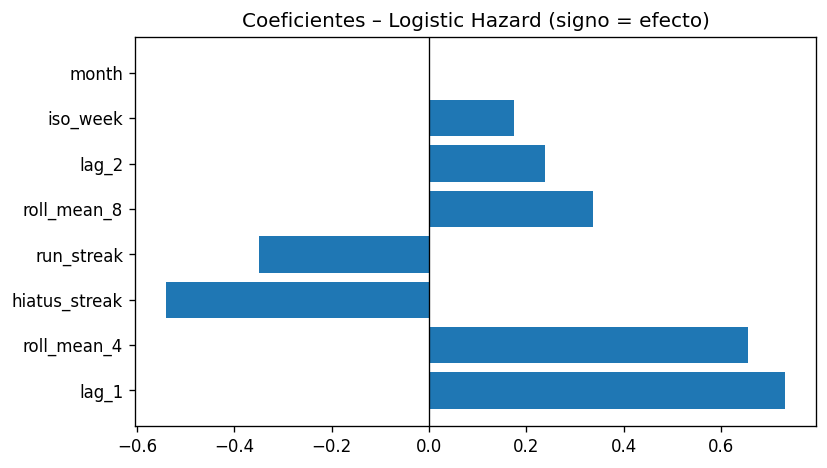

In [52]:
# ==== BLOQUE 5 (NUEVO): Modelo 1 – Logistic Hazard + importancias ====
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# dataset de hazard: sólo semanas en hiatus (donde tiene sentido que la próxima semana inicie un run)
mask_hiatus = (weekly['has_chapter']==0)
data_h = weekly.loc[mask_hiatus].copy()

hazard_feats = [
    'hiatus_streak','run_streak',
    'roll_mean_4','roll_mean_8',
    'lag_1','lag_2',
    'month','iso_week'
]
y_h = data_h['start_next']
X_h = data_h[hazard_feats]

Xh_train = X_h.loc[data_h['week_start'] < split_date]
yh_train = y_h.loc[data_h['week_start'] < split_date]
Xh_test  = X_h.loc[data_h['week_start'] >= buffer_date]
yh_test  = y_h.loc[data_h['week_start'] >= buffer_date]

pipe_hazard = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(
        penalty='elasticnet', solver='saga',
        max_iter=5000, l1_ratio=0.5, class_weight='balanced', random_state=42
    ))
]).fit(Xh_train, yh_train)

prob_h_test = pipe_hazard.predict_proba(Xh_test)[:,1]
pred_h_test = (prob_h_test >= 0.5).astype(int)

print("=== Hazard (hiatus-only) ===")
print("Accuracy:", round(accuracy_score(yh_test, pred_h_test),3))
print("F1     :", round(f1_score(yh_test, pred_h_test),3))
print("ROC-AUC:", round(roc_auc_score(yh_test, prob_h_test),3))
print(classification_report(yh_test, pred_h_test))

# --- Importancias (coeficientes) ---
coef = pipe_hazard.named_steps['lr'].coef_[0]
haz_imp = (
    pd.DataFrame({'feature': hazard_feats, 'coef': coef, 'abs_coef': np.abs(coef)})
      .sort_values('abs_coef', ascending=False)
)
display(haz_imp)

plt.figure(figsize=(7,4))
plt.barh(haz_imp['feature'], haz_imp['coef'])
plt.title("Coeficientes – Logistic Hazard (signo = efecto)")
plt.axvline(0, color='k', lw=0.8); plt.tight_layout(); plt.show()

# Probabilidad histórica (para usar luego si quieres)
weekly['prob_hazard_t'] = 0.0
weekly.loc[mask_hiatus, 'prob_hazard_t'] = pipe_hazard.predict_proba(X_h)[:,1]


Best iter: 826  | Best score: 0.11865373906822732
=== XGB ===
Accuracy: 0.976
F1     : 0.4
ROC-AUC: 0.716
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       484
           1       0.40      0.40      0.40        10

    accuracy                           0.98       494
   macro avg       0.69      0.69      0.69       494
weighted avg       0.98      0.98      0.98       494



,feature,importance
1,run_streak,60.069202
2,lag_1,46.702515
4,roll_mean_4,23.365255
0,hiatus_streak,19.412851
3,lag_2,13.356639
5,roll_mean_8,10.302570
6,t_idx,7.907810
12,issue_cos,3.246155
8,month_cos,3.220472
10,iso_week_cos,3.035155


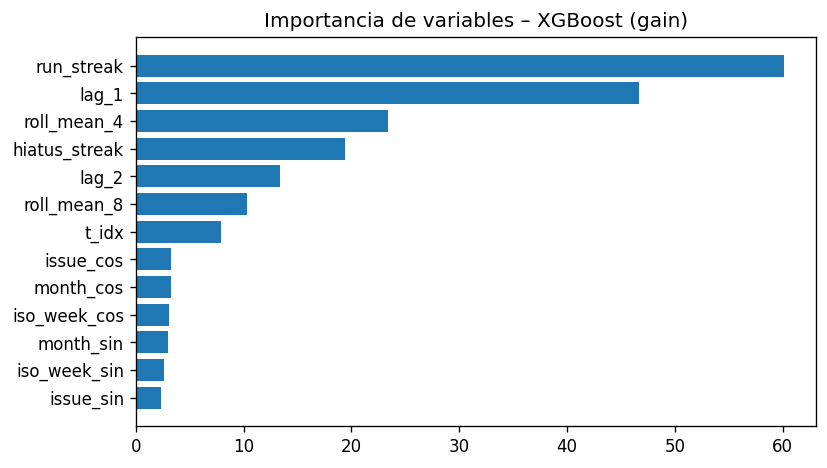

In [53]:
# ==== BLOQUE 6 (NUEVO): Modelo 2 – XGBoost + importancias ====
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

xgb_feats = [
    'hiatus_streak','run_streak','lag_1','lag_2',
    'roll_mean_4','roll_mean_8',
    't_idx','month_sin','month_cos','iso_week_sin','iso_week_cos',
    'issue_sin','issue_cos'
]
X = weekly[xgb_feats].fillna(0)
y = weekly['start_of_run']

Xtr, Xte = X.loc[train_idx], X.loc[test_idx]
ytr, yte = y.loc[train_idx], y.loc[test_idx]

dtr = xgb.DMatrix(Xtr, label=ytr, feature_names=xgb_feats)
dte = xgb.DMatrix(Xte, label=yte, feature_names=xgb_feats)

posw = (ytr.value_counts()[0] / max(1, ytr.value_counts()[1])) if ytr.sum() else 1.0
mono = "(+1,-1,0,0,0,0,0,0,0,0,0,0,0)"  # hiatus ↑, run ↓

params = dict(
    objective="binary:logistic",
    eval_metric=["auc","logloss"],
    eta=0.03, max_depth=2,
    min_child_weight=10, subsample=0.6, colsample_bytree=0.6,
    reg_lambda=12.0, reg_alpha=5.0, gamma=0.0,
    tree_method="hist", scale_pos_weight=float(posw), seed=42,
    monotone_constraints=mono
)

bst = xgb.train(
    params=params, dtrain=dtr, num_boost_round=1200,
    evals=[(dtr,"train"),(dte,"valid")],
    early_stopping_rounds=100, verbose_eval=False
)
print("Best iter:", bst.best_iteration, " | Best score:", bst.best_score)

# evaluación
yprob_xgb = bst.predict(dte)
ypred_xgb = (yprob_xgb >= 0.5).astype(int)
print("=== XGB ===")
print("Accuracy:", round(accuracy_score(yte, ypred_xgb),3))
print("F1     :", round(f1_score(yte, ypred_xgb),3))
print("ROC-AUC:", round(roc_auc_score(yte, yprob_xgb),3))
print(classification_report(yte, ypred_xgb))

# --- Importancias (gain) ---
imp_xgb = bst.get_score(importance_type='gain')
imp_xgb_df = (pd.DataFrame({'feature': list(imp_xgb.keys()), 'importance': list(imp_xgb.values())})
              .sort_values('importance', ascending=False))
display(imp_xgb_df)

plt.figure(figsize=(7,4))
plt.barh(imp_xgb_df['feature'], imp_xgb_df['importance'])
plt.title("Importancia de variables – XGBoost (gain)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

# Probabilidad histórica (si quieres graficar luego)
weekly['prob_xgb_t'] = bst.predict(xgb.DMatrix(X, feature_names=xgb_feats))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== NN (MLP) con class_weight ===
Umbral óptimo F1: 0.252
Accuracy: 0.978
F1     : 0.421
ROC-AUC: 0.835
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       484
           1       0.44      0.40      0.42        10

    accuracy                           0.98       494
   macro avg       0.72      0.69      0.70       494
weighted avg       0.98      0.98      0.98       494



,feature,weight_abs_sum
2,lag_1,8.452236
1,run_streak,7.120834
3,lag_2,5.974012
6,t_idx,5.554692
0,hiatus_streak,5.121297
9,iso_week_sin,4.739077
7,month_sin,4.695946
4,roll_mean_4,4.659638
5,roll_mean_8,4.652672
11,issue_sin,4.491209


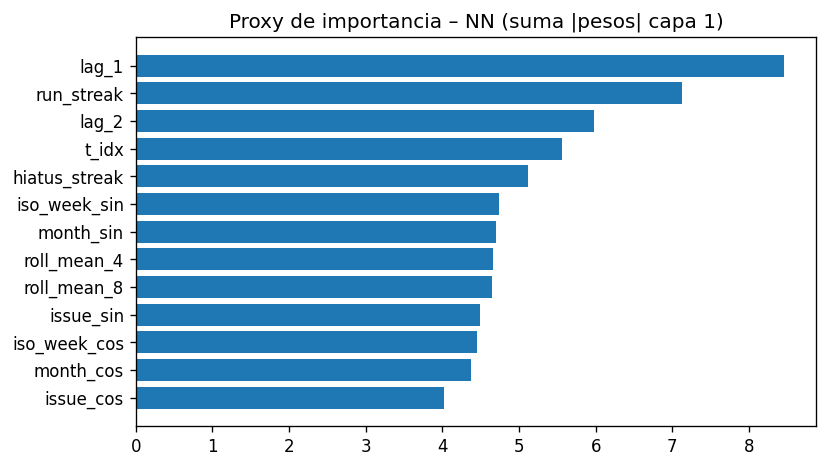

In [54]:
# ==== BLOQUE 7 (NUEVO): Modelo 3 – NN (MLP) con class_weight + importancias básicas ====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve

# Escalar (fit en TRAIN únicamente)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

# Pesos de clase para penalizar más los positivos (runs)
n_pos = int(ytr.sum()); n_neg = int((1 - ytr).sum())
class_weight = {0: 1.0, 1: max(5.0, n_neg / max(1, n_pos))}  # mínimo 5x

nn = keras.Sequential([
    layers.Input(shape=(Xtr_s.shape[1],)),
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3)),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3)),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])
nn.compile(optimizer=keras.optimizers.Adam(5e-4),
           loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='AUC')])

cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                   restore_best_weights=True, verbose=0)
hist = nn.fit(Xtr_s, ytr, validation_data=(Xte_s, yte),
              epochs=250, batch_size=64, callbacks=[cb],
              class_weight=class_weight, verbose=0)

# Probabilidades en TEST
yprob_nn = nn.predict(Xte_s).ravel()

# Umbral óptimo por F1 (PR curve)
from sklearn.metrics import precision_recall_curve
pr, rc, thr = precision_recall_curve(yte, yprob_nn)
f1s = 2*pr*rc/(pr+rc+1e-12)
best_idx = int(np.argmax(f1s))
thr_opt = float(thr[max(0, best_idx-1)]) if len(thr) else 0.5

# Si NO marca positivos, fuerza un umbral por top-k (k ≈ positivos reales en test)
k_pos = int(max(1, yte.sum()))
if (yprob_nn >= thr_opt).sum() == 0:
    cutoff = np.sort(yprob_nn)[-k_pos]
    thr_opt = min(thr_opt, cutoff)

ypred_nn = (yprob_nn >= thr_opt).astype(int)


print("=== NN (MLP) con class_weight ===")
print("Umbral óptimo F1:", round(float(thr_opt), 3))
print("Accuracy:", round(accuracy_score(yte, ypred_nn),3))
print("F1     :", round(f1_score(yte, ypred_nn),3))
print("ROC-AUC:", round(roc_auc_score(yte, yprob_nn),3))
print(classification_report(yte, ypred_nn))

# Proxy de importancia – toma la PRIMERA capa con pesos (evita Dropout/Input) ===
first_weighted_layer = next(l for l in nn.layers if len(l.get_weights()) > 0)
W0 = first_weighted_layer.get_weights()[0]   # (n_features, n_units)
w0 = np.abs(W0).sum(axis=1)                  # suma |pesos| por feature

nn_imp_df = pd.DataFrame({'feature': xgb_feats, 'weight_abs_sum': w0}) \
              .sort_values('weight_abs_sum', ascending=False)
display(nn_imp_df)


plt.figure(figsize=(7,4))
plt.barh(nn_imp_df['feature'], nn_imp_df['weight_abs_sum'])
plt.title("Proxy de importancia – NN (suma |pesos| capa 1)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

# Probabilidad histórica NN (sólo para TEST; si quieres todo, recuerda: scaler.transform(X))
weekly['prob_nn_t'] = 0.0
weekly.loc[test_idx, 'prob_nn_t'] = yprob_nn
nn_thr_opt = float(thr_opt)  # guardamos para futuro


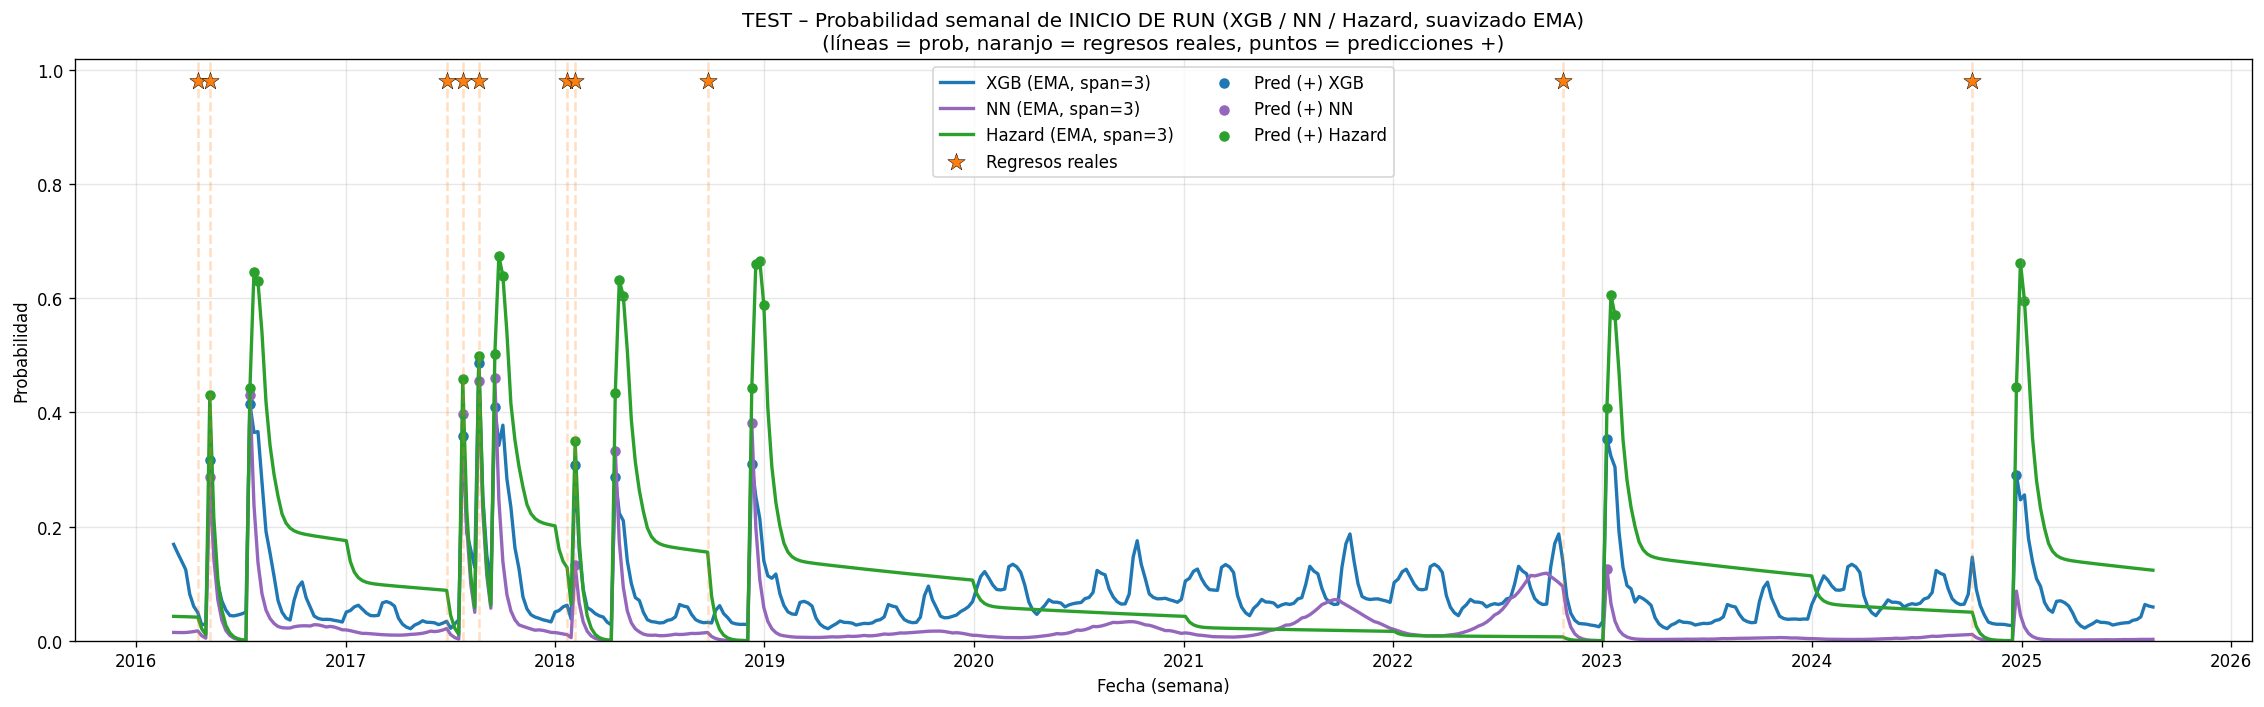

📅 Regresos REALES en test: [datetime.date(2016, 4, 18), datetime.date(2016, 5, 9), datetime.date(2017, 6, 26), datetime.date(2017, 7, 24), datetime.date(2017, 8, 21), datetime.date(2018, 1, 22), datetime.date(2018, 2, 5), datetime.date(2018, 9, 24), datetime.date(2022, 10, 24), datetime.date(2024, 10, 7)]
🔮 Fechas predichas (Hazard): [datetime.date(2016, 5, 9), datetime.date(2016, 7, 18), datetime.date(2016, 7, 25), datetime.date(2016, 8, 1), datetime.date(2017, 7, 24), datetime.date(2017, 8, 21), datetime.date(2017, 9, 18), datetime.date(2017, 9, 25), datetime.date(2017, 10, 2), datetime.date(2018, 2, 5), datetime.date(2018, 4, 16), datetime.date(2018, 4, 23), datetime.date(2018, 4, 30), datetime.date(2018, 12, 10), datetime.date(2018, 12, 17), datetime.date(2018, 12, 24), datetime.date(2018, 12, 31), datetime.date(2023, 1, 9), datetime.date(2023, 1, 16), datetime.date(2023, 1, 23), datetime.date(2024, 12, 23), datetime.date(2024, 12, 30), datetime.date(2025, 1, 6)]
🔮 Fechas predichas

In [55]:
# ==== BLOQUE 8 (FINAL, con EMA y sin zoom) ====
from pandas import Timedelta

# --- 1) Preparar series de probabilidad alineadas al TEST ---
dates_test = weekly.loc[test_idx, 'week_start'].reset_index(drop=True)
p_xgb_test = pd.Series(yprob_xgb, index=pd.to_datetime(dates_test))
p_nn_test  = pd.Series(yprob_nn,  index=pd.to_datetime(dates_test))

# Hazard: prob de "inicio en t+1" → desplazada a t
p_h_all = pd.Series(0.0, index=weekly.index)
mask_hiatus = (weekly['has_chapter'] == 0)
p_h_all.loc[mask_hiatus] = pipe_hazard.predict_proba(
    weekly.loc[mask_hiatus, ['hiatus_streak','run_streak','roll_mean_4','roll_mean_8','lag_1','lag_2','month','iso_week']]
)[:, 1]
p_h_test = pd.Series(p_h_all.shift(1).fillna(0.0).loc[test_idx].values,
                     index=pd.to_datetime(dates_test))

# --- 2) Suavizado EMA (sin lag, más “reactivo”) ---
def ema(s, span=3):
    return s.ewm(span=span, adjust=False).mean()

p_xgb_s = ema(p_xgb_test, 3)
p_nn_s  = ema(p_nn_test,  3)
p_h_s   = ema(p_h_test,   3)

# --- 3) Fechas reales y predichas ---
real_test_dates = pd.to_datetime(weekly.loc[test_idx & (weekly['start_of_run']==1), 'week_start'])

thr_xgb = 0.5
thr_haz = 0.5
thr_nn  = nn_thr_opt if 'nn_thr_opt' in locals() else 0.5

pred_xgb_dates = p_xgb_test.index[p_xgb_test >= thr_xgb]
pred_nn_dates  = p_nn_test.index[p_nn_test   >= thr_nn]
pred_haz_dates = p_h_test.index[p_h_test     >= thr_haz]

# --- 4) Paleta consistente ---
COL_XGB = "#1f77b4"   # azul
COL_NN  = "#9467bd"   # morado
COL_HAZ = "#2ca02c"   # verde
COL_REAL= "#ff7f0e"   # naranja

# =======================
# Gráfico general con EMA
# =======================
plt.figure(figsize=(19,6))
plt.plot(p_xgb_s.index, p_xgb_s.values, color=COL_XGB, lw=2, label="XGB (EMA, span=3)")
plt.plot(p_nn_s.index,  p_nn_s.values,  color=COL_NN,  lw=2, label="NN (EMA, span=3)")
plt.plot(p_h_s.index,   p_h_s.values,   color=COL_HAZ, lw=2, label="Hazard (EMA, span=3)")

# Regresos reales (líneas + estrellas)
for d in real_test_dates:
    plt.axvline(d, color=COL_REAL, alpha=0.25, ls="--")
plt.scatter(real_test_dates, [0.98]*len(real_test_dates),
            marker="*", s=120, color=COL_REAL, edgecolors="k", linewidths=0.3,
            label="Regresos reales")

# Puntos predichos (mismo color que curva)
plt.scatter(pred_xgb_dates, p_xgb_s.loc[pred_xgb_dates],
            color=COL_XGB, s=28, label="Pred (+) XGB")
plt.scatter(pred_nn_dates,  p_nn_s.loc[pred_nn_dates],
            color=COL_NN,  s=28, label="Pred (+) NN")
plt.scatter(pred_haz_dates, p_h_s.loc[pred_haz_dates],
            color=COL_HAZ, s=28, label="Pred (+) Hazard")

plt.title("TEST – Probabilidad semanal de INICIO DE RUN (XGB / NN / Hazard, suavizado EMA)\n"
          "(líneas = prob, naranjo = regresos reales, puntos = predicciones +)")
plt.xlabel("Fecha (semana)")
plt.ylabel("Probabilidad")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# --- 5) Listas de fechas (opcional) ---
to_dates = lambda s: [d.date() for d in pd.to_datetime(s)]
print("📅 Regresos REALES en test:", to_dates(real_test_dates))
print("🔮 Fechas predichas (Hazard):", to_dates(pred_haz_dates))
print("🔮 Fechas predichas (XGB)   :", to_dates(pred_xgb_dates))
print("🔮 Fechas predichas (NN)    :", to_dates(pred_nn_dates))


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


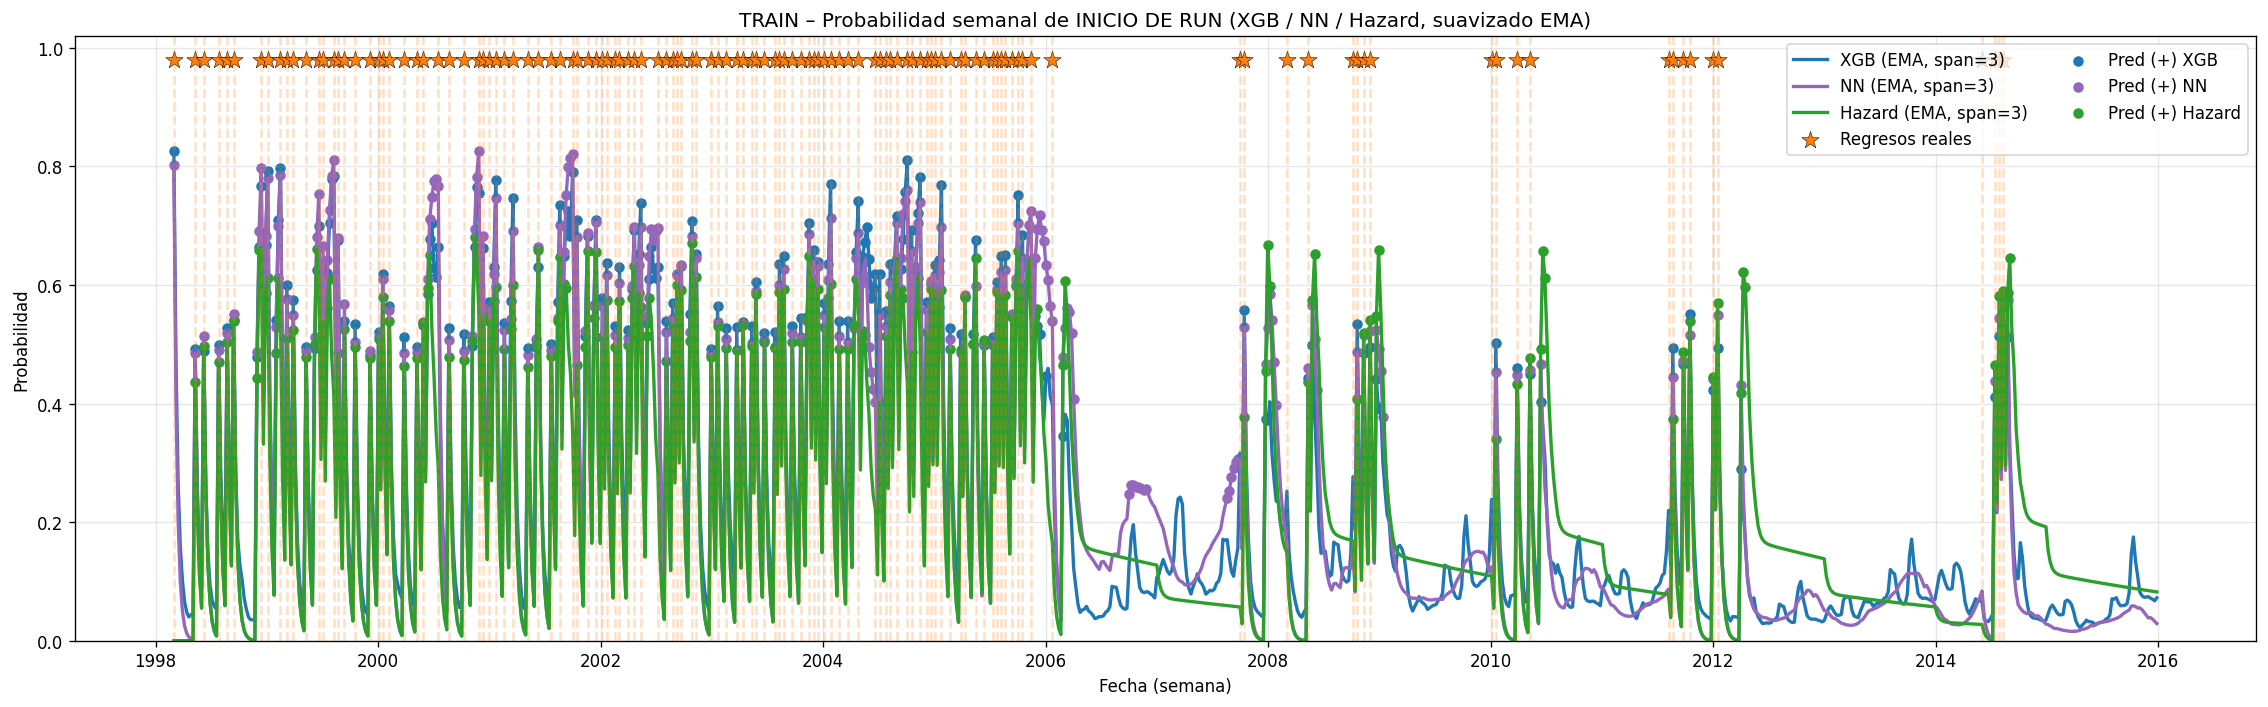

In [56]:
# ==== BLOQUE 8 — EXTRA: mismas curvas pero en TRAIN ====

# --- 1) Probabilidades por modelo en TRAIN, alineadas por fecha ---
dates_train = weekly.loc[train_idx, 'week_start'].reset_index(drop=True)

# XGB
yprob_xgb_tr = bst.predict(xgb.DMatrix(Xtr, feature_names=xgb_feats))
p_xgb_train  = pd.Series(yprob_xgb_tr, index=pd.to_datetime(dates_train))

# NN (ojo: usar el mismo scaler)
yprob_nn_tr = nn.predict(scaler.transform(Xtr)).ravel()
p_nn_train  = pd.Series(yprob_nn_tr, index=pd.to_datetime(dates_train))

# Hazard: prob de "inicio en t+1" → desplazar a t y tomar solo TRAIN
p_h_all = pd.Series(0.0, index=weekly.index)
mask_hiatus = (weekly['has_chapter'] == 0)
p_h_all.loc[mask_hiatus] = pipe_hazard.predict_proba(
    weekly.loc[mask_hiatus, ['hiatus_streak','run_streak','roll_mean_4','roll_mean_8','lag_1','lag_2','month','iso_week']]
)[:, 1]
p_h_train = pd.Series(p_h_all.shift(1).fillna(0.0).loc[train_idx].values,
                      index=pd.to_datetime(dates_train))

# --- 2) Suavizado EMA (mismo span que en TEST) ---
def ema(s, span=3):
    return s.ewm(span=span, adjust=False).mean()

p_xgb_tr_s = ema(p_xgb_train, 3)
p_nn_tr_s  = ema(p_nn_train,  3)
p_h_tr_s   = ema(p_h_train,   3)

# --- 3) Fechas reales y umbrales para marcar "positivos" ---
real_train_dates = pd.to_datetime(weekly.loc[train_idx & (weekly['start_of_run']==1), 'week_start'])

thr_xgb = 0.5
thr_haz = 0.5
thr_nn  = nn_thr_opt if 'nn_thr_opt' in locals() else 0.5

pred_xgb_tr_dates = p_xgb_train.index[p_xgb_train >= thr_xgb]
pred_nn_tr_dates  = p_nn_train.index[p_nn_train   >= thr_nn]
pred_haz_tr_dates = p_h_train.index[p_h_train     >= thr_haz]

# --- 4) Misma paleta que en TEST ---
COL_XGB = "#1f77b4"   # azul
COL_NN  = "#9467bd"   # morado
COL_HAZ = "#2ca02c"   # verde
COL_REAL= "#ff7f0e"   # naranja

# =======================
# Gráfico TRAIN con EMA
# =======================
plt.figure(figsize=(19,6))
plt.plot(p_xgb_tr_s.index, p_xgb_tr_s.values, color=COL_XGB, lw=2, label="XGB (EMA, span=3)")
plt.plot(p_nn_tr_s.index,  p_nn_tr_s.values,  color=COL_NN,  lw=2, label="NN (EMA, span=3)")
plt.plot(p_h_tr_s.index,   p_h_tr_s.values,   color=COL_HAZ, lw=2, label="Hazard (EMA, span=3)")

# Regresos reales (líneas + estrellas)
for d in real_train_dates:
    plt.axvline(d, color=COL_REAL, alpha=0.25, ls="--")
plt.scatter(real_train_dates, [0.98]*len(real_train_dates),
            marker="*", s=120, color=COL_REAL, edgecolors="k", linewidths=0.3,
            label="Regresos reales")

# Puntos de "positivo" sobre la curva suavizada (para que coincidan en altura)
plt.scatter(pred_xgb_tr_dates, p_xgb_tr_s.loc[pred_xgb_tr_dates],
            color=COL_XGB, s=28, label="Pred (+) XGB")
plt.scatter(pred_nn_tr_dates,  p_nn_tr_s.loc[pred_nn_tr_dates],
            color=COL_NN,  s=28, label="Pred (+) NN")
plt.scatter(pred_haz_tr_dates, p_h_tr_s.loc[pred_haz_tr_dates],
            color=COL_HAZ, s=28, label="Pred (+) Hazard")

plt.title("TRAIN – Probabilidad semanal de INICIO DE RUN (XGB / NN / Hazard, suavizado EMA)")
plt.xlabel("Fecha (semana)")
plt.ylabel("Probabilidad")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


In [57]:
# ==== FUTURO 0: construir semanas a 10 años ====
from datetime import timedelta

horizon_weeks = 520  # ~10 años
wk = weekly['week_start'].max() + timedelta(weeks=1)

# Estado inicial: asumimos seguimos en hiatus (no hay capítulo) y rachas reseteadas
hs = int(weekly['hiatus_streak'].iloc[-1] + 1)  # hiatus crece semana a semana
rs = 0
l1 = 0; l2 = 0
r4 = 0.0; r8 = 0.0

rows = []
for i in range(horizon_weeks):
    rows.append(dict(
        hiatus_streak = hs,
        run_streak    = rs,
        lag_1 = l1, lag_2 = l2,
        roll_mean_4 = r4, roll_mean_8 = r8,
        t_idx = weekly['t_idx'].iloc[-1] + (i+1),
        month = wk.month,
        iso_week = wk.isocalendar().week,
        month_sin    = np.sin(2*np.pi*wk.month/12),
        month_cos    = np.cos(2*np.pi*wk.month/12),
        iso_week_sin = np.sin(2*np.pi*wk.isocalendar().week/52),
        iso_week_cos = np.cos(2*np.pi*wk.isocalendar().week/52),
        issue_sin    = np.sin(2*np.pi*wk.isocalendar().week/52),
        issue_cos    = np.cos(2*np.pi*wk.isocalendar().week/52),
        week_start = wk
    ))
    wk += timedelta(weeks=1)
    hs += 1

future_df_10y = pd.DataFrame(rows)


🔮 TOP fechas probables (Hazard, 10 años):


,Fecha,prob_hazard_future,Prob_norm


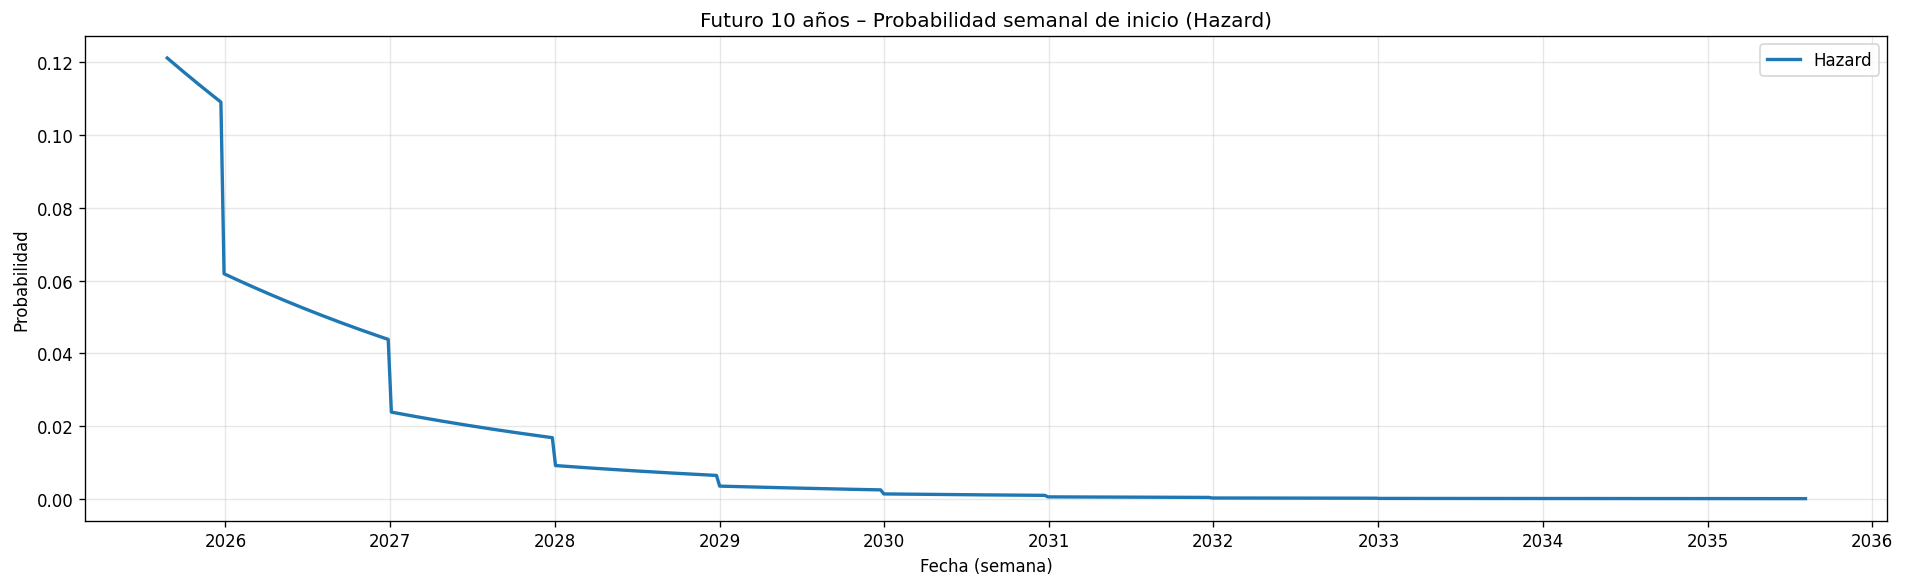

In [58]:
# ==== FUTURO 1: Hazard (top fechas y gráfico) ====
from scipy.signal import find_peaks

# Probabilidad futura hazard (usa features del hazard)
Xh_future = future_df_10y[['hiatus_streak','run_streak','roll_mean_4','roll_mean_8','lag_1','lag_2','month','iso_week']]
p_h_future = pipe_hazard.predict_proba(Xh_future)[:,1]
future_df_10y['prob_hazard_future'] = p_h_future

# Picos (mínimo 5 semanas de separación)
idxs, _ = find_peaks(future_df_10y['prob_hazard_future'].values, distance=5)
cand = future_df_10y.iloc[idxs][['week_start','prob_hazard_future']].copy()
cand = cand.sort_values('prob_hazard_future', ascending=False).head(15)
cand['Fecha'] = cand['week_start'].dt.date
cand['Prob_norm'] = (cand['prob_hazard_future'] / cand['prob_hazard_future'].max()).round(3) if len(cand) else 0.0

print("🔮 TOP fechas probables (Hazard, 10 años):")
display(cand[['Fecha','prob_hazard_future','Prob_norm']])

plt.figure(figsize=(16,5))
plt.plot(future_df_10y['week_start'], future_df_10y['prob_hazard_future'], label='Hazard', lw=2)
plt.title("Futuro 10 años – Probabilidad semanal de inicio (Hazard)")
plt.xlabel("Fecha (semana)"); plt.ylabel("Probabilidad"); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


🔮 TOP fechas probables (XGB, 10 años):


,Fecha,prob_xgb_future,Prob_norm
111,2027-10-11,0.211385,1.000
58,2026-10-05,0.211385,1.000
476,2034-10-09,0.211385,1.000
371,2032-10-04,0.211385,1.000
215,2029-10-08,0.211385,1.000
163,2028-10-09,0.211385,1.000
424,2033-10-10,0.211385,1.000
267,2030-10-07,0.211385,1.000
319,2031-10-06,0.211385,1.000
445,2034-03-06,0.168738,0.798


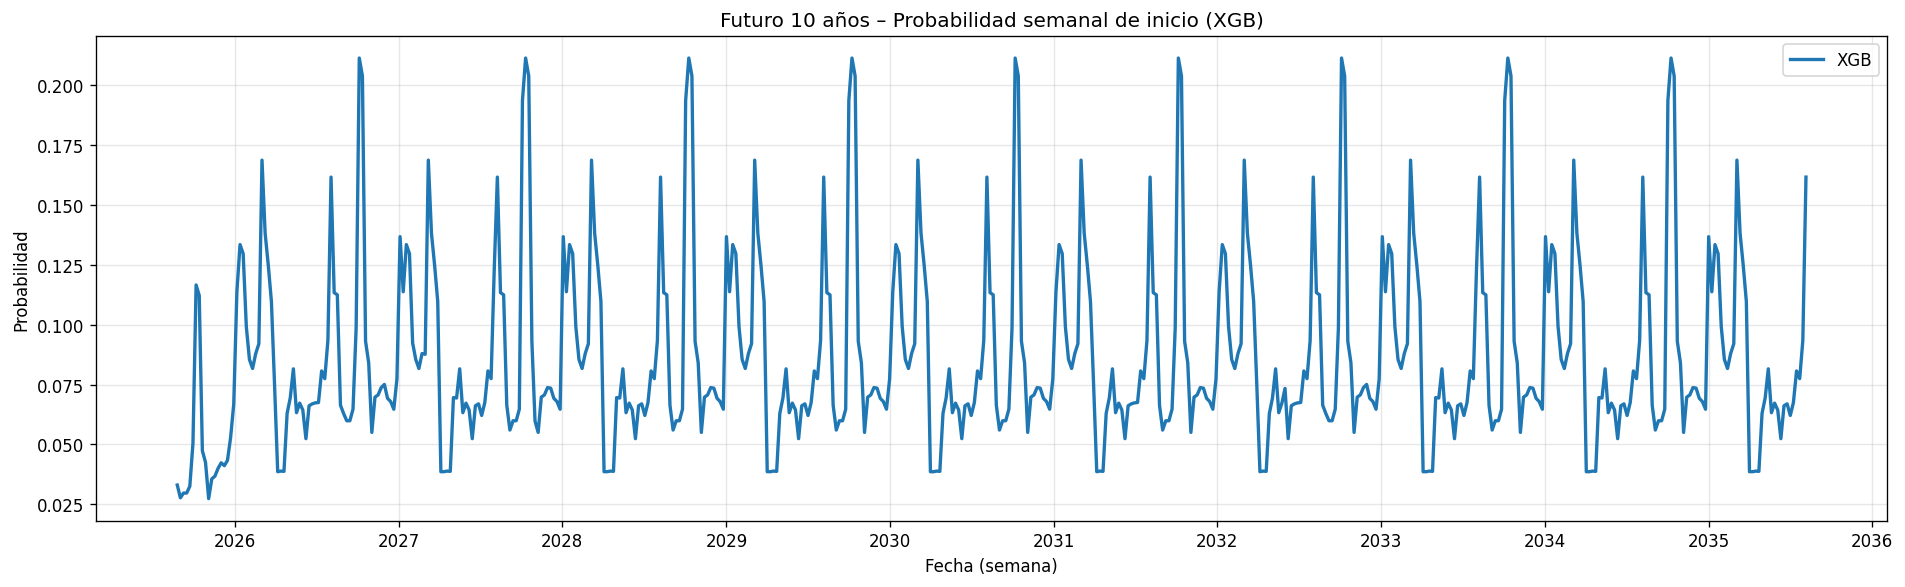

In [59]:
# ==== FUTURO 2: XGBoost (top fechas y gráfico) ====
from scipy.signal import find_peaks
import xgboost as xgb

xgb_feats = [
    'hiatus_streak','run_streak','lag_1','lag_2',
    'roll_mean_4','roll_mean_8',
    't_idx','month_sin','month_cos','iso_week_sin','iso_week_cos',
    'issue_sin','issue_cos'
]
p_xgb_future = bst.predict(xgb.DMatrix(future_df_10y[xgb_feats], feature_names=xgb_feats))
future_df_10y['prob_xgb_future'] = p_xgb_future

idxs, _ = find_peaks(future_df_10y['prob_xgb_future'].values, distance=5)
cand = future_df_10y.iloc[idxs][['week_start','prob_xgb_future']].copy()
cand = cand.sort_values('prob_xgb_future', ascending=False).head(15)
cand['Fecha'] = cand['week_start'].dt.date
cand['Prob_norm'] = (cand['prob_xgb_future'] / cand['prob_xgb_future'].max()).round(3) if len(cand) else 0.0

print("🔮 TOP fechas probables (XGB, 10 años):")
display(cand[['Fecha','prob_xgb_future','Prob_norm']])

plt.figure(figsize=(16,5))
plt.plot(future_df_10y['week_start'], future_df_10y['prob_xgb_future'], label='XGB', lw=2)
plt.title("Futuro 10 años – Probabilidad semanal de inicio (XGB)")
plt.xlabel("Fecha (semana)"); plt.ylabel("Probabilidad"); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
🔮 TOP fechas probables (NN, 10 años):


,Fecha,prob_nn_future,Prob_norm
366,2032-08-30,0.126247,1.000
470,2034-08-28,0.125816,0.997
418,2033-08-29,0.122311,0.969
518,2035-07-30,0.119703,0.948
361,2032-07-26,0.098740,0.782
413,2033-07-25,0.095360,0.755
313,2031-08-25,0.087477,0.693
513,2035-06-25,0.072129,0.571
461,2034-06-26,0.067454,0.534
261,2030-08-26,0.058369,0.462


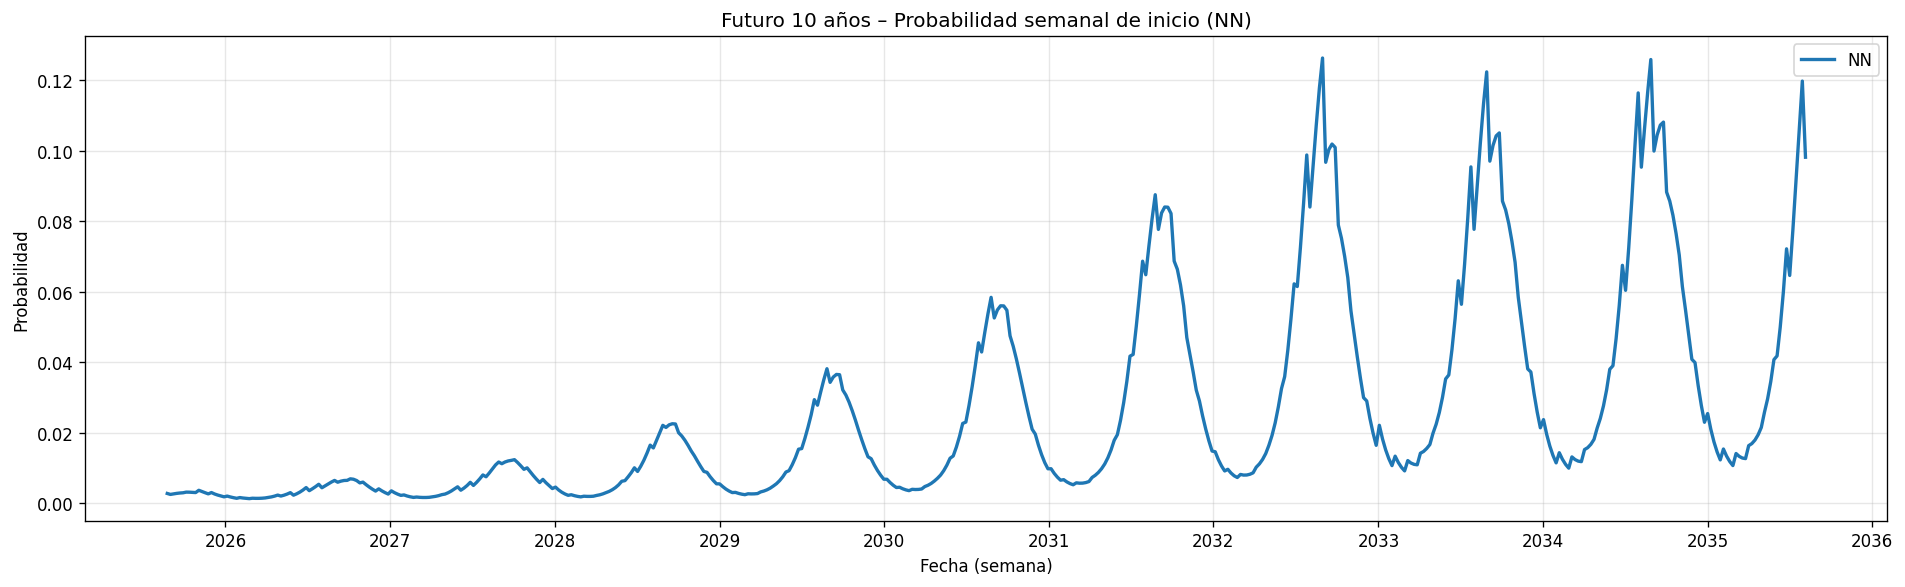

In [60]:
# ==== FUTURO 3: NN (top fechas y gráfico) ====
from scipy.signal import find_peaks

nn_threshold = nn_thr_opt if 'nn_thr_opt' in locals() else 0.5

p_nn_future = nn.predict(scaler.transform(future_df_10y[xgb_feats])).ravel()
future_df_10y['prob_nn_future'] = p_nn_future

idxs, _ = find_peaks(future_df_10y['prob_nn_future'].values, distance=5)
cand = future_df_10y.iloc[idxs][['week_start','prob_nn_future']].copy()
cand = cand.sort_values('prob_nn_future', ascending=False).head(15)
cand['Fecha'] = cand['week_start'].dt.date
cand['Prob_norm'] = (cand['prob_nn_future'] / cand['prob_nn_future'].max()).round(3) if len(cand) else 0.0

print("🔮 TOP fechas probables (NN, 10 años):")
display(cand[['Fecha','prob_nn_future','Prob_norm']])

plt.figure(figsize=(16,5))
plt.plot(future_df_10y['week_start'], future_df_10y['prob_nn_future'], label='NN', lw=2)
plt.title("Futuro 10 años – Probabilidad semanal de inicio (NN)")
plt.xlabel("Fecha (semana)"); plt.ylabel("Probabilidad"); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


📌 Monte Carlo — Mediana: 2025-09-29 | P25: 2025-09-08 | P75: 2025-11-03

🏆 Fechas más frecuentes (Top-10):


,Fecha,Simulaciones
0,2025-08-25,2430
1,2025-09-01,2107
2,2025-09-08,1922
3,2025-09-15,1614
4,2025-09-22,1430
5,2025-09-29,1186
6,2025-10-06,1095
7,2025-10-13,993
8,2025-10-20,863
9,2025-10-27,756


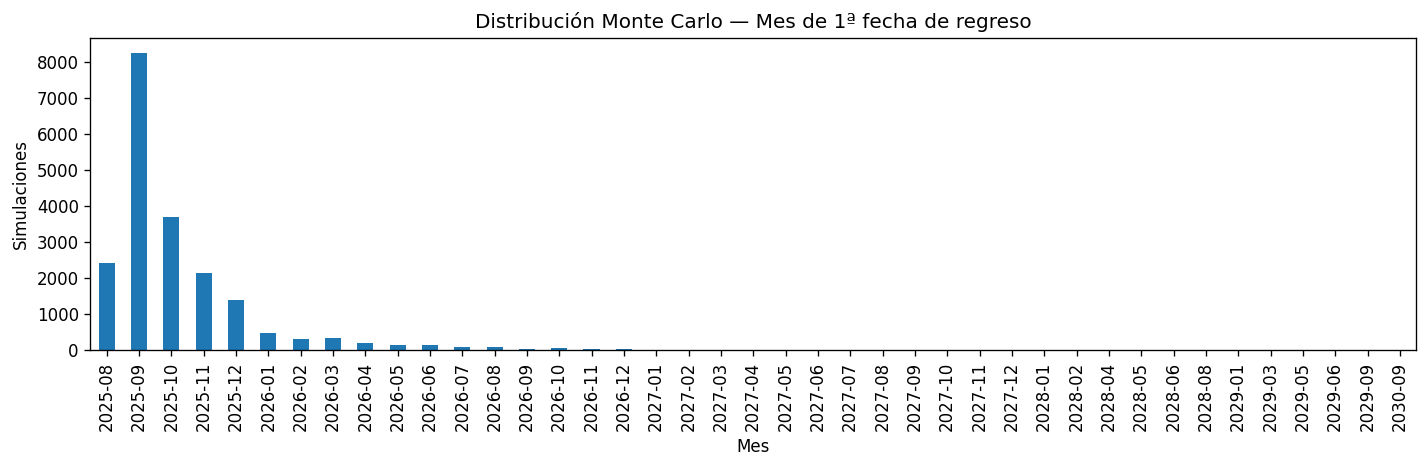

💾 Guardado: mc_first_hit_dates.csv  (n=19980)
💾 Guardado: mc_top10_dates.csv
💾 Guardado: mc_summary.csv


In [61]:
# ==== FUTURO 4 (Monte Carlo, robusto y con export) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# --- 0) Asegurar FUTURO base (10 años) y prob_hazard_future ---
def _build_future_10y(weekly, horizon_weeks=520):
    wk = weekly['week_start'].max() + timedelta(weeks=1)
    hs = int(weekly['hiatus_streak'].iloc[-1] + 1)  # asumimos seguimos en hiatus
    rs = 0; l1 = 0; l2 = 0; r4 = 0.0; r8 = 0.0
    rows = []
    for i in range(horizon_weeks):
        rows.append(dict(
            hiatus_streak=hs, run_streak=rs, lag_1=l1, lag_2=l2,
            roll_mean_4=r4, roll_mean_8=r8,
            t_idx=weekly['t_idx'].iloc[-1] + (i+1),
            month=wk.month,
            iso_week=wk.isocalendar().week,
            month_sin=np.sin(2*np.pi*wk.month/12),
            month_cos=np.cos(2*np.pi*wk.month/12),
            iso_week_sin=np.sin(2*np.pi*wk.isocalendar().week/52),
            iso_week_cos=np.cos(2*np.pi*wk.isocalendar().week/52),
            issue_sin=np.sin(2*np.pi*wk.isocalendar().week/52),
            issue_cos=np.cos(2*np.pi*wk.isocalendar().week/52),
            week_start=wk
        ))
        wk += timedelta(weeks=1); hs += 1
    return pd.DataFrame(rows)

# Construir future_df_10y si no existe
if 'future_df_10y' not in globals():
    future_df_10y = _build_future_10y(weekly, horizon_weeks=520)

# Calcular prob_hazard_future si no existe
hazard_feats = ['hiatus_streak','run_streak','roll_mean_4','roll_mean_8','lag_1','lag_2','month','iso_week']
if 'prob_hazard_future' not in future_df_10y.columns:
    Xh_future = future_df_10y[hazard_feats].copy()
    future_df_10y['prob_hazard_future'] = pipe_hazard.predict_proba(Xh_future)[:,1]

# --- 1) Parámetros de simulación ---
N_SIM = 20000          # sube a 100_000 si lo dejas mucho rato
BATCH = 5000           # tamaño de lote (controla RAM)
RANDOM_SEED = 42

p = np.clip(future_df_10y['prob_hazard_future'].values, 1e-9, 1-1e-9)
dates = pd.to_datetime(future_df_10y['week_start']).values
T = len(p)

rng = np.random.default_rng(RANDOM_SEED)
first_hit_idx = np.full(N_SIM, -1, dtype=np.int32)

# --- 2) Simulación por lotes (vectorizada) ---
sims_done = 0
while sims_done < N_SIM:
    bs = min(BATCH, N_SIM - sims_done)
    # U: bs x T
    U = rng.random((bs, T))
    hits = (U < p)  # True donde hay "éxito" esa semana
    # idx del primer éxito por fila o -1 si ninguno
    # truco: poner a T (fuera de rango) cuando no hay éxito y luego reemplazar por -1
    first_idx = hits.argmax(axis=1)
    no_hit = ~hits.any(axis=1)
    first_idx[no_hit] = -1
    first_hit_idx[sims_done:sims_done+bs] = first_idx
    sims_done += bs

# --- 3) Post-proceso de resultados ---
valid = first_hit_idx >= 0
first_dates = pd.to_datetime(dates[first_hit_idx[valid]])

summary = {}
if len(first_dates):
    # Convertir a Serie para usar métodos estadísticos
    fd_series = pd.Series(first_dates)
    med = fd_series.median()
    p25 = fd_series.quantile(0.25)
    p75 = fd_series.quantile(0.75)
    summary = {
        "N_sim": int(N_SIM),
        "Mediana": med.date().isoformat(),
        "P25": p25.date().isoformat(),
        "P75": p75.date().isoformat(),
        "Horizonte_meses": int(len(future_df_10y)/4.33)
    }
    print(f"📌 Monte Carlo — Mediana: {med.date()} | P25: {p25.date()} | P75: {p75.date()}")
else:
    print("⚠️ Ninguna simulación tuvo regreso en el horizonte. Considera ampliar horizon_weeks o revisar p(t).")

# Top-10 fechas más frecuentes
if len(first_dates):
    top_mode = first_dates.value_counts().sort_values(ascending=False).head(10)
    top_df = pd.DataFrame({
        "Fecha": top_mode.index.date,
        "Simulaciones": top_mode.values
    })
    print("\n🏆 Fechas más frecuentes (Top-10):")
    display(top_df)
else:
    top_df = pd.DataFrame(columns=["Fecha","Simulaciones"])

# Histograma por mes (opcional)
if len(first_dates):
    by_month = first_dates.to_period('M').value_counts().sort_index()
    plt.figure(figsize=(12,4))
    by_month.plot(kind='bar')
    plt.title("Distribución Monte Carlo — Mes de 1ª fecha de regreso")
    plt.xlabel("Mes"); plt.ylabel("Simulaciones")
    plt.tight_layout(); plt.show()

# --- 4) Exportar resultados a CSV (para tu tabla final / GitHub) ---
# 4a) Todas las primeras fechas (una por simulación válida)
if len(first_dates):
    mc_dates_df = pd.DataFrame({"first_date": first_dates.date})
    mc_dates_path = "mc_first_hit_dates.csv"
    mc_dates_df.to_csv(mc_dates_path, index=False)
    print(f"💾 Guardado: {mc_dates_path}  (n={len(mc_dates_df)})")

# 4b) Resumen y top-10
mc_summary_df = pd.DataFrame([summary]) if summary else pd.DataFrame()
mc_top_path = "mc_top10_dates.csv"
top_df.to_csv(mc_top_path, index=False)
print(f"💾 Guardado: {mc_top_path}")

mc_summary_path = "mc_summary.csv"
mc_summary_df.to_csv(mc_summary_path, index=False)
print(f"💾 Guardado: {mc_summary_path}")

# --- 5) (Opcional) Tabla “executive” mínima si ya existen top_haz/top_xgb/top_nn ---
def _safe_top(tbl, name, k=3):
    if isinstance(tbl, pd.DataFrame) and not tbl.empty:
        out = tbl.copy().head(k)[["Fecha"]].reset_index(drop=True)
        out.columns = [name]
        return out
    return pd.DataFrame({name: []})

try:
    exec_tbl = pd.DataFrame()
    exec_tbl = exec_tbl.join(_safe_top(globals().get('top_haz'), "Hazard_top3"), how='outer')
    exec_tbl = exec_tbl.join(_safe_top(globals().get('top_xgb'), "XGB_top3"), how='outer')
    exec_tbl = exec_tbl.join(_safe_top(globals().get('top_nn'),  "NN_top3"),  how='outer')

    if not mc_summary_df.empty:
        exec_tbl["MC_Mediana"] = mc_summary_df["Mediana"].iloc[0]
        exec_tbl["MC_P25"]     = mc_summary_df["P25"].iloc[0]
        exec_tbl["MC_P75"]     = mc_summary_df["P75"].iloc[0]

    if not exec_tbl.empty:
        exec_path = "executive_dates_summary.csv"
        exec_tbl.to_csv(exec_path, index=False)
        print(f"💾 Guardado resumen ejecutivo: {exec_path}")
        display(exec_tbl)
except Exception as e:
    print("Nota: no se construyó la tabla ejecutiva (faltaban top_* o hubo un error menor).", e)


Ahora el modelo definitivo

In [62]:
# ==== BLOQUE 9A (actualizado): Estacionalidad empírica + breaks históricos ====
from sklearn.neighbors import KernelDensity
import numpy as np
import pandas as pd

# --- 1. Densidad de regresos históricos (KDE circular en iso_week)
wknum = weekly['iso_week'].values.reshape(-1, 1)
wknum_returns = weekly.loc[weekly['start_of_run'] == 1, 'iso_week'].values.reshape(-1, 1)

if len(wknum_returns) > 0:
    # duplicamos ±52 para continuidad circular
    x_kde = np.vstack([wknum_returns, wknum_returns + 52, wknum_returns - 52])
    kde = KernelDensity(kernel='gaussian', bandwidth=2.0).fit(x_kde)
    dens = np.exp(kde.score_samples(wknum))
    # normalizamos con np.ptp (NumPy ≥2.0)
    dens = (dens - dens.min()) / (np.ptp(dens) + 1e-12)
else:
    dens = np.zeros(len(wknum))

weekly['issue_kde'] = dens  # señal estacional de regresos

# --- 2. Probabilidad empírica de "break" (ausencia de capítulo) por semana del año ---
wk_stats = (
    weekly.groupby('iso_week')['has_chapter']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'mean_has_chapter'})
)
wk_stats['mean_no_chapter'] = 1 - wk_stats['mean_has_chapter']

# Suavizado opcional con rolling circular (para no castigar semanas aisladas)
wk_stats['break_prob_smooth'] = (
    wk_stats['mean_no_chapter'].rolling(3, center=True, min_periods=1).mean()
)

# Asignamos al dataset
weekly = weekly.merge(
    wk_stats[['break_prob_smooth']],
    how='left', left_on='iso_week', right_index=True
)
weekly['week_break_prob'] = weekly['break_prob_smooth'].fillna(0)

# --- 3. Feature final para modelo ---
extra_feats = ['issue_kde', 'week_break_prob']

print("✅ Features añadidas:")
print(" - issue_kde: densidad de regresos históricos (KDE circular)")
print(" - week_break_prob: probabilidad empírica de break según datos históricos")


✅ Features añadidas:
 - issue_kde: densidad de regresos históricos (KDE circular)
 - week_break_prob: probabilidad empírica de break según datos históricos


In [63]:
# ==== BLOQUE 9B: Prior de hazard creciente vs hiatus_streak ====
from sklearn.isotonic import IsotonicRegression

# Entrenamos un prior: P(start_next | hiatus_streak) solo en HIATUS (como el hazard)
mask_hiatus = (weekly['has_chapter']==0)
df_h = weekly.loc[mask_hiatus, ['hiatus_streak','start_next']].copy()

# Bin promedio de start_next por valor de hiatus_streak (suaviza el ruido)
grp = df_h.groupby('hiatus_streak')['start_next'].mean().reset_index()
x_hs = grp['hiatus_streak'].values
y_rate = grp['start_next'].values

# Isotónico creciente
iso = IsotonicRegression(y_min=0.0, y_max=1.0, increasing=True, out_of_bounds='clip')
iso.fit(x_hs, y_rate)

# Prior sobre todo el weekly
weekly['prior_hazard'] = iso.predict(weekly['hiatus_streak'].values)


In [64]:
# ==== BLOQUE 9C: Modelos base con búsqueda y calibración ====
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# Features para XGB/NN (sumamos extra_feats):
xgb_feats_final = [
    'hiatus_streak','run_streak','lag_1','lag_2','roll_mean_4','roll_mean_8',
    't_idx','month_sin','month_cos','iso_week_sin','iso_week_cos','issue_sin','issue_cos'
] + extra_feats

X_full = weekly[xgb_feats_final].fillna(0)
y_full = weekly['start_of_run']

# Split temporal (usamos el corte train/test que ya tienes)
Xtr, Xte = X_full.loc[train_idx], X_full.loc[test_idx]
ytr, yte = y_full.loc[train_idx], y_full.loc[test_idx]

# --- XGBoost con monotonicidad (hiatus +, run -)
mono = "(+1,-1,0,0,0,0,0,0,0,0,0,0,0" + ",0"*len(extra_feats) + ")"
posw = (ytr.value_counts()[0] / max(1, ytr.value_counts()[1])) if ytr.sum() else 1.0

xgb_base = xgb.XGBClassifier(
    objective='binary:logistic', tree_method='hist',
    monotone_constraints=mono, scale_pos_weight=float(posw),
    eval_metric='auc', random_state=42, n_estimators=1200
)

param_dist = {
    'max_depth': [2,3,4],
    'learning_rate': [0.01,0.03,0.05],
    'subsample': [0.6,0.8,1.0],
    'colsample_bytree':[0.6,0.8,1.0],
    'min_child_weight':[5,10,20],
    'reg_lambda':[1,5,10,15],
    'reg_alpha':[0,2,5]
}
tscv = TimeSeriesSplit(n_splits=4)
xgb_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=25, cv=tscv,
    scoring='roc_auc', verbose=0, random_state=42, n_jobs=-1
)
xgb_search.fit(Xtr, ytr)

xgb_best = xgb_search.best_estimator_

# Calibración isotónica del XGB sobre TRAIN (cv interna)
xgb_cal = CalibratedClassifierCV(xgb_best, method='isotonic', cv=tscv)
xgb_cal.fit(Xtr, ytr)

# --- Logistic base (elastic net) con class_weight + calibración
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logit_pipe = Pipeline([
    ('sc', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=5000,
        l1_ratio=0.5, class_weight='balanced', random_state=42))
])
logit_cal = CalibratedClassifierCV(logit_pipe, method='isotonic', cv=tscv)
logit_cal.fit(Xtr, ytr)


CalibratedClassifierCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None),
                       estimator=Pipeline(steps=[('sc',
                                                  StandardScaler(with_mean=False)),
                                                 ('lr',
                                                  LogisticRegression(class_weight='balanced',
                                                                     l1_ratio=0.5,
                                                                     max_iter=5000,
                                                                     penalty='elasticnet',
                                                                     random_state=42,
                                                                     solver='saga'))]),
                       method='isotonic')

In [65]:
# ==== BLOQUE 9D (actualizado): Ensamble con prior + reglas empíricas de breaks ====
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report

def blend_prob(p_xgb, p_log, prior, issue_kde, week_break_prob):
    """Matriz de meta-variables para el meta-learner (stacking)."""
    Z = np.vstack([
        p_xgb, p_log, prior,
        issue_kde,
        week_break_prob
    ]).T
    return Z

# Probabilidades base (train/test) ya calibradas
p_xgb_tr = xgb_cal.predict_proba(Xtr)[:,1]
p_xgb_te = xgb_cal.predict_proba(Xte)[:,1]

p_log_tr = logit_cal.predict_proba(Xtr)[:,1]
p_log_te = logit_cal.predict_proba(Xte)[:,1]

# Priors y señales
prior_tr = weekly.loc[train_idx, 'prior_hazard'].values
prior_te = weekly.loc[test_idx,  'prior_hazard'].values

kde_tr   = weekly.loc[train_idx, 'issue_kde'].values
kde_te   = weekly.loc[test_idx,  'issue_kde'].values

# NUEVO: breaks empíricos (en vez de holidays)
brk_tr   = weekly.loc[train_idx, 'week_break_prob'].values
brk_te   = weekly.loc[test_idx,  'week_break_prob'].values

Z_tr = blend_prob(p_xgb_tr, p_log_tr, prior_tr, kde_tr, brk_tr)
Z_te = blend_prob(p_xgb_te, p_log_te, prior_te, kde_te, brk_te)

# Meta-learner (stacking): logistic CV con class_weight
meta = LogisticRegressionCV(
    Cs=10, cv=tscv, max_iter=5000, class_weight='balanced',
    solver='lbfgs', scoring='roc_auc', n_jobs=-1
)
meta.fit(Z_tr, ytr)

p_ens_te = meta.predict_proba(Z_te)[:,1]

# ===== Reglas post-proceso =====
def postprocess_probs_empirical(df_slice, p, window_exclusion=8, alpha_kde=0.15, beta_break=0.35):
    """
    df_slice: porción de weekly alineada a p (mismo índice)
    p: probabilidades base (ensamble)
    - Ventana de exclusión: baja prob. hasta ~8 semanas tras un regreso real (en test/train).
    - Modulación por estacionalidad (issue_kde) hacia arriba.
    - Penalización empírica por 'week_break_prob' hacia abajo.
    """
    p2 = p.copy()

    # 1) Ventana de exclusión tras un start_of_run real (evita falsos picos cercanos)
    starts = df_slice['start_of_run'].fillna(0).values
    cool = 0
    for i in range(len(p2)):
        if starts[i] == 1:
            cool = window_exclusion
        if cool > 0:
            p2[i] *= 0.25
            cool -= 1

    # 2) Modulación suave por estacionalidad de regresos
    p2 = p2 * (1 + alpha_kde * df_slice['issue_kde'].values)

    # 3) Penalización empírica por semana con alta prob. histórica de NO capítulo
    p2 = p2 * (1 - beta_break * df_slice['week_break_prob'].values)

    # 4) clip
    return np.clip(p2, 1e-6, 1-1e-6)

pp_te = postprocess_probs_empirical(weekly.loc[test_idx], p_ens_te)

# Métricas finales en TEST
yhat = (pp_te >= 0.5).astype(int)
print("=== Ensamble Final + reglas (TEST) ===")
print("Accuracy:", round(accuracy_score(yte, yhat),3))
print("F1     :", round(f1_score(yte, yhat),3))
print("ROC-AUC:", round(roc_auc_score(yte, pp_te),3))
print(classification_report(yte, yhat))


=== Ensamble Final + reglas (TEST) ===
Accuracy: 0.98
F1     : 0.0
ROC-AUC: 0.105
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       484
           1       0.00      0.00      0.00        10

    accuracy                           0.98       494
   macro avg       0.49      0.50      0.49       494
weighted avg       0.96      0.98      0.97       494



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


🎯 TOP-15 fechas candidatas (modelo definitivo):


,Fecha,prob_final,Prob_norm,issue_kde,week_break_prob,prior_hazard
58,2026-10-05,0.452495,1.000,0.879779,0.679012,0.018807
267,2030-10-07,0.451954,0.999,0.879779,0.679012,1.000000
319,2031-10-06,0.451954,0.999,0.879779,0.679012,1.000000
371,2032-10-04,0.451954,0.999,0.879779,0.679012,1.000000
110,2027-10-04,0.438836,0.970,0.796435,0.703704,0.018807
162,2028-10-02,0.438464,0.969,0.796435,0.703704,0.018807
214,2029-10-01,0.438458,0.969,0.796435,0.703704,1.000000
423,2033-10-03,0.438458,0.969,0.796435,0.703704,1.000000
475,2034-10-02,0.438458,0.969,0.796435,0.703704,1.000000
80,2027-03-08,0.386782,0.855,0.151959,0.639330,0.018807


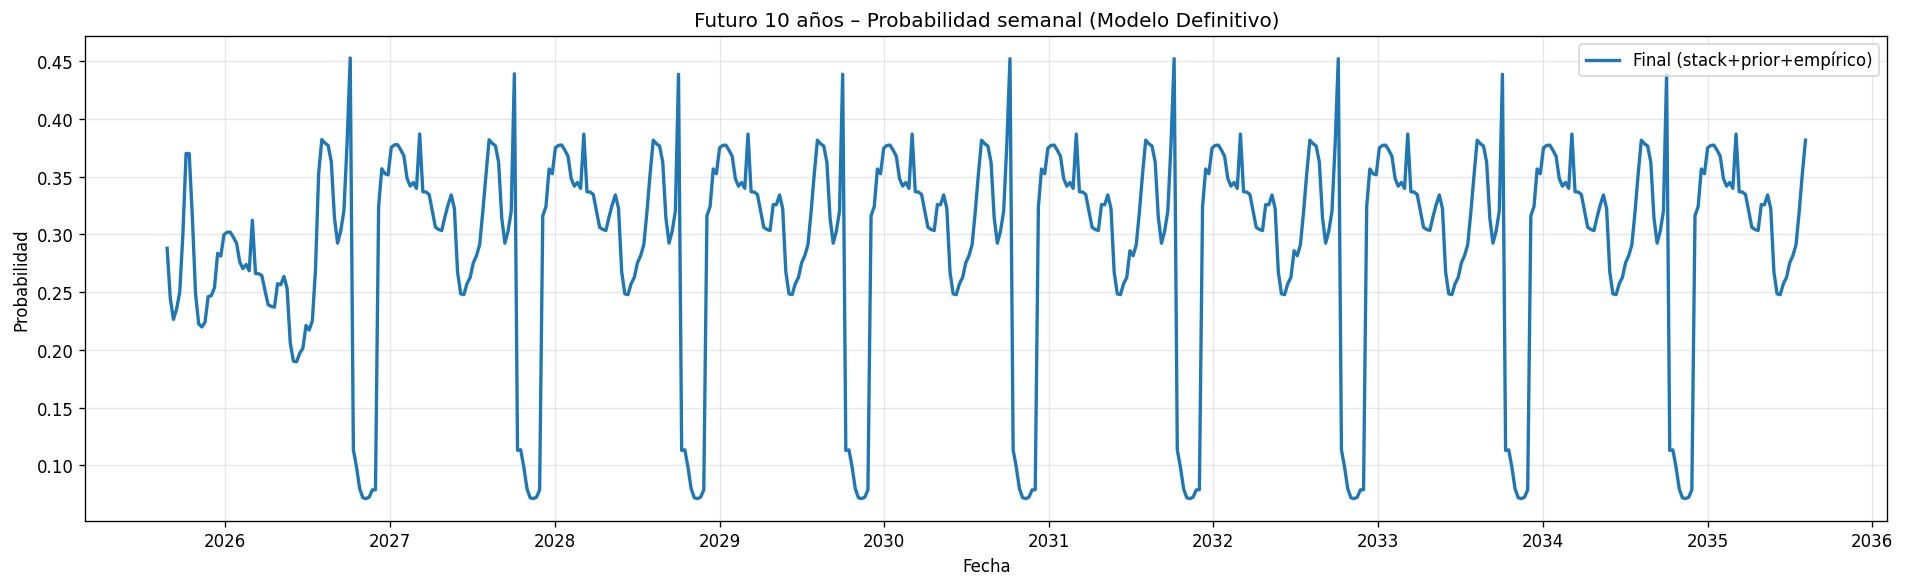

💾 Guardados:
 - final_top_dates_modelo_definitivo.csv
 - timeline_prob_modelo_definitivo.csv


In [66]:
# ==== BLOQUE 9E (completo): Futuro 10 años con modelo definitivo (empírico) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -------------------------------
# 1) Construcción del FUTURO (10 años)
# -------------------------------
horizon_weeks = 520  # ~10 años
if 'future_df_10y' not in globals():
    wk = weekly['week_start'].max() + pd.Timedelta(weeks=1)
    hs = int(weekly['hiatus_streak'].iloc[-1] + 1)  # asumimos seguimos en hiatus
    rs = 0; l1 = 0; l2 = 0; r4 = 0.0; r8 = 0.0
    rows = []
    for i in range(horizon_weeks):
        rows.append(dict(
            hiatus_streak=hs, run_streak=rs, lag_1=l1, lag_2=l2,
            roll_mean_4=r4, roll_mean_8=r8,
            t_idx=weekly['t_idx'].iloc[-1] + (i+1),
            month=wk.month, iso_week=wk.isocalendar().week,
            month_sin=np.sin(2*np.pi*wk.month/12),
            month_cos=np.cos(2*np.pi*wk.month/12),
            iso_week_sin=np.sin(2*np.pi*wk.isocalendar().week/52),
            iso_week_cos=np.cos(2*np.pi*wk.isocalendar().week/52),
            issue_sin=np.sin(2*np.pi*wk.isocalendar().week/52),
            issue_cos=np.cos(2*np.pi*wk.isocalendar().week/52),
            week_start=wk
        ))
        wk += pd.Timedelta(weeks=1)
        hs += 1
    future_df_10y = pd.DataFrame(rows)

# -------------------------------
# 2) Señales empíricas para el FUTURO
#    - issue_kde: densidad de regresos históricos (KDE circular)
#    - week_break_prob: prob. empírica de "no capítulo" por iso_week
#    (Requiere que en 9A hayas entrenado `kde`, `wknum_returns`, `wk_stats`)
# -------------------------------
wknum_f = future_df_10y['iso_week'].values.reshape(-1,1)

# issue_kde futuro con el KDE entrenado en 9A
if 'kde' in globals() and len(wknum_returns) > 0:
    dens_f = np.exp(kde.score_samples(wknum_f))
    dens_f = (dens_f - dens_f.min())/(np.ptp(dens_f) + 1e-12)
else:
    dens_f = np.zeros(len(future_df_10y), dtype=float)
future_df_10y['issue_kde'] = dens_f

# week_break_prob futuro usando las estadísticas históricas (wk_stats de 9A)
if 'wk_stats' in globals() and 'break_prob_smooth' in wk_stats.columns:
    future_df_10y = future_df_10y.merge(
        wk_stats[['break_prob_smooth']],
        how='left', left_on='iso_week', right_index=True
    )
    future_df_10y['week_break_prob'] = future_df_10y['break_prob_smooth'].fillna(
        wk_stats['break_prob_smooth'].mean()
    )
    future_df_10y.drop(columns=['break_prob_smooth'], inplace=True, errors='ignore')
else:
    # fallback: si no hay wk_stats, usar 0.5 plano
    future_df_10y['week_break_prob'] = 0.5

# Prior isotónico en el futuro (entrenado en 9B)
future_df_10y['prior_hazard'] = iso.predict(future_df_10y['hiatus_streak'].values)

# -------------------------------
# 3) Probabilidad base del ensamble en el FUTURO
#    (usa los calibrados xgb_cal, logit_cal; meta viene del 9D)
# -------------------------------
# Asegúrate de que xgb_feats_final incluya ['issue_kde','week_break_prob']
Xf = future_df_10y[xgb_feats_final].fillna(0)

p_xgb_fu = xgb_cal.predict_proba(Xf)[:,1]
p_log_fu = logit_cal.predict_proba(Xf)[:,1]

def blend_prob(p_xgb, p_log, prior, issue_kde, week_break_prob):
    """Matriz Z para meta-learner (stacking)"""
    return np.vstack([p_xgb, p_log, prior, issue_kde, week_break_prob]).T

Z_f = blend_prob(
    p_xgb_fu, p_log_fu,
    future_df_10y['prior_hazard'].values,
    future_df_10y['issue_kde'].values,
    future_df_10y['week_break_prob'].values
)
p_ens_fu = meta.predict_proba(Z_f)[:,1]

# -------------------------------
# 4) Reglas de negocio al futuro
#    - Ventana de exclusión tras "hit" predicho (evita clusters irreales)
#    - Modulación por issue_kde (alza suave)
#    - Penalización por week_break_prob (baja empírica)
# -------------------------------
pp_fu = p_ens_fu.copy()

window_exclusion = 8
cool = 0
for i in range(len(pp_fu)):
    # Si supera umbral, consideramos "hit" y abrimos ventana
    if pp_fu[i] >= 0.5 and cool == 0:
        cool = window_exclusion
    elif cool > 0:
        pp_fu[i] *= 0.25
        cool -= 1

# Modulación empírica
pp_fu = pp_fu * (1 + 0.15 * future_df_10y['issue_kde'].values)
pp_fu = pp_fu * (1 - 0.35 * future_df_10y['week_break_prob'].values)
pp_fu = np.clip(pp_fu, 1e-6, 1-1e-6)

future_df_10y['prob_final'] = pp_fu

# -------------------------------
# 5) Selección de TOP fechas (picos) y gráfico
# -------------------------------
idxs, _ = find_peaks(pp_fu, distance=5)
cand = future_df_10y.iloc[idxs][['week_start','prob_final','issue_kde','week_break_prob','prior_hazard']].copy()
cand = cand.sort_values('prob_final', ascending=False).head(15)
cand['Fecha'] = cand['week_start'].dt.date
cand['Prob_norm'] = (cand['prob_final']/cand['prob_final'].max()).round(3)

print("🎯 TOP-15 fechas candidatas (modelo definitivo):")
display(cand[['Fecha','prob_final','Prob_norm','issue_kde','week_break_prob','prior_hazard']])

plt.figure(figsize=(16,5))
plt.plot(future_df_10y['week_start'], future_df_10y['prob_final'], label='Final (stack+prior+empírico)', lw=2)
plt.title("Futuro 10 años – Probabilidad semanal (Modelo Definitivo)")
plt.xlabel("Fecha"); plt.ylabel("Probabilidad")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# -------------------------------
# 6) Exportar CSVs para GitHub
# -------------------------------
final_exec = cand[['Fecha','prob_final','issue_kde','week_break_prob','prior_hazard']].copy()
final_exec.columns = ['Fecha_predicha','Probabilidad','issue_kde','week_break_prob','prior_hazard']
final_exec.to_csv("final_top_dates_modelo_definitivo.csv", index=False)

timeline_out = future_df_10y[['week_start','prob_final','issue_kde','week_break_prob','prior_hazard']].copy()
timeline_out.columns = ['week_start','prob_final','issue_kde','week_break_prob','prior_hazard']
timeline_out.to_csv("timeline_prob_modelo_definitivo.csv", index=False)

print("💾 Guardados:")
print(" - final_top_dates_modelo_definitivo.csv")
print(" - timeline_prob_modelo_definitivo.csv")


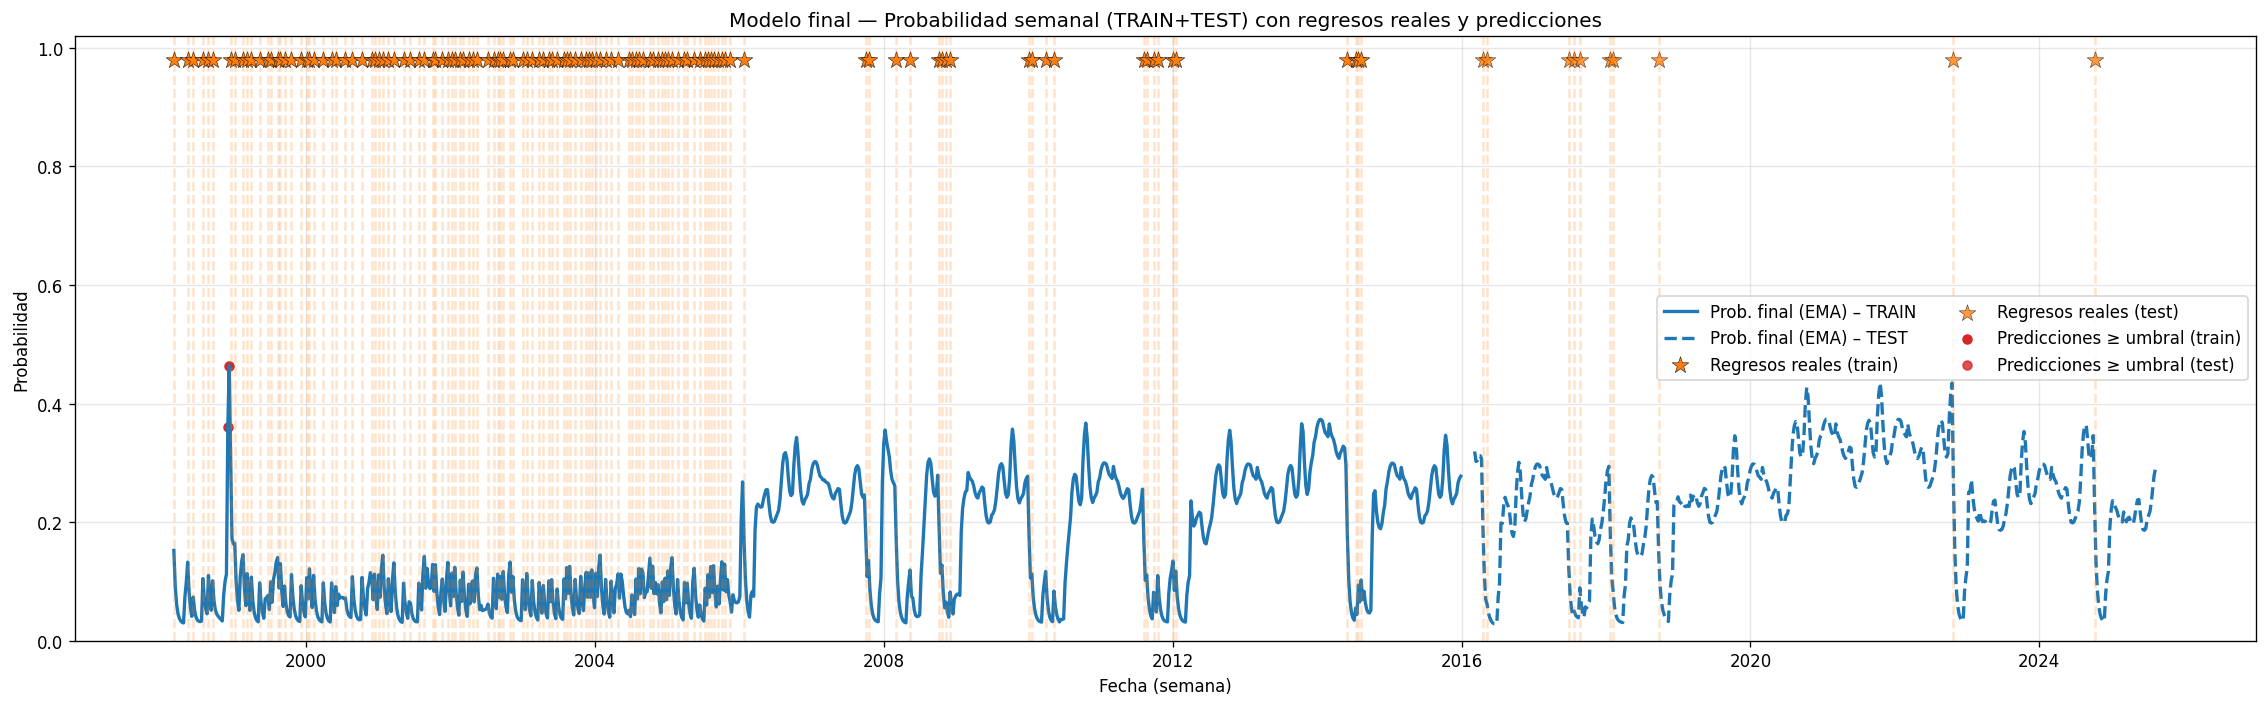

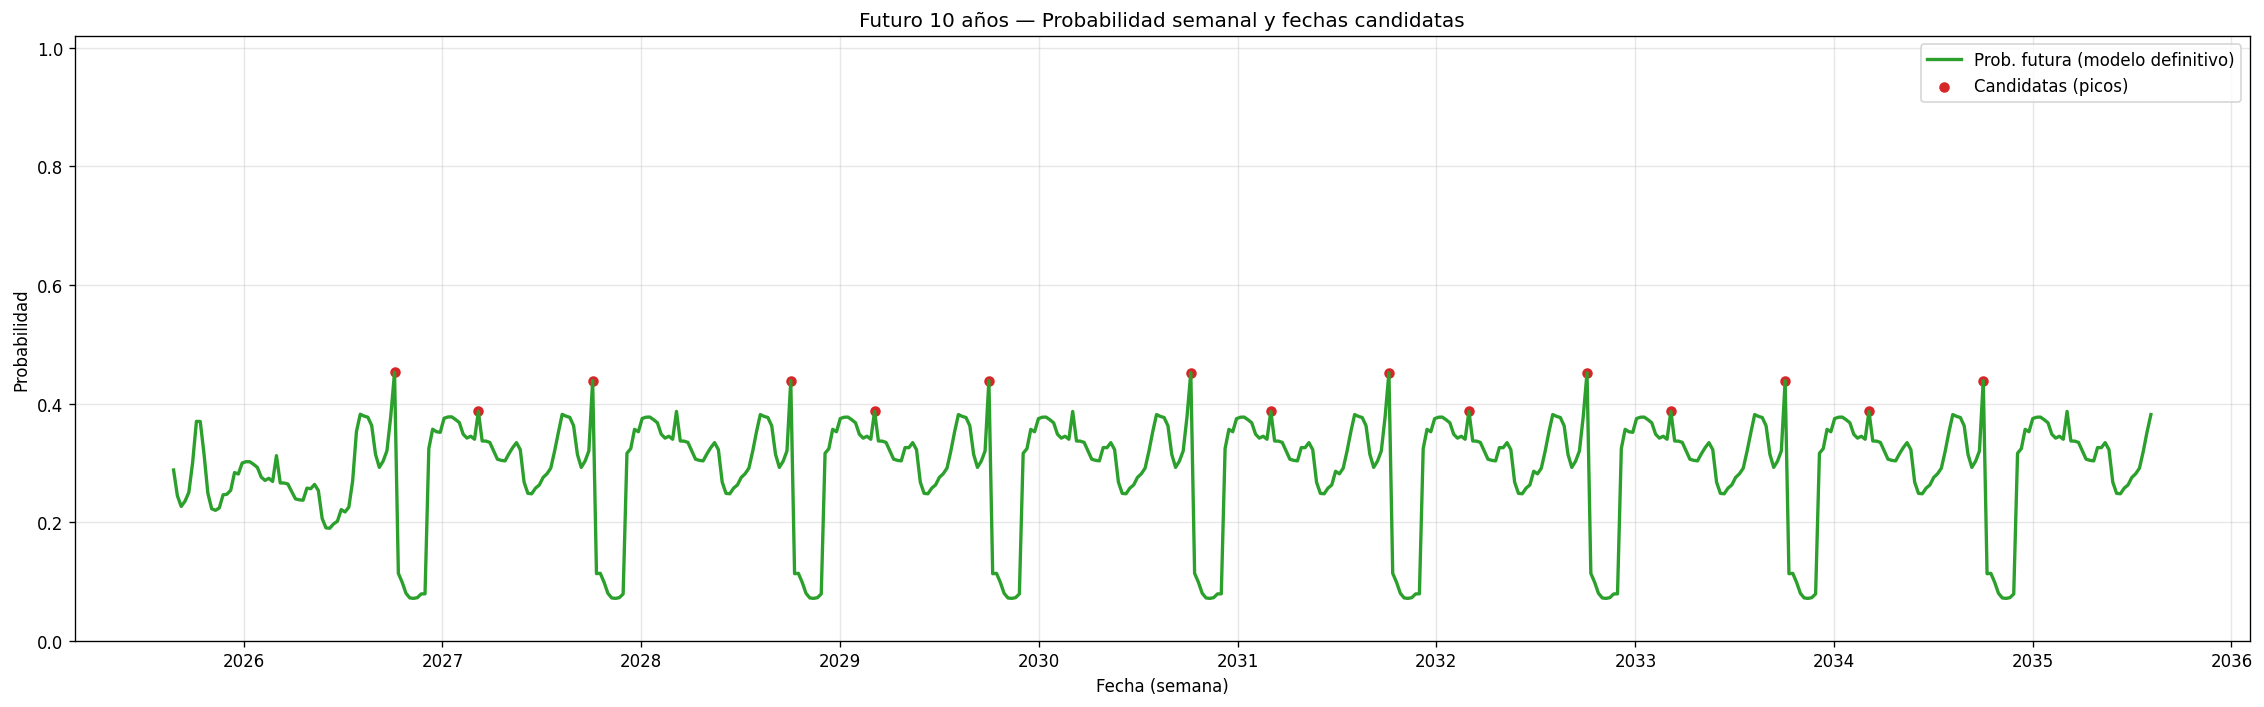

📅 Regresos REALES (TRAIN): [datetime.date(1998, 3, 2), datetime.date(1998, 5, 11), datetime.date(1998, 6, 8), datetime.date(1998, 7, 27), datetime.date(1998, 8, 24), datetime.date(1998, 9, 14), datetime.date(1998, 12, 14), datetime.date(1999, 1, 4), datetime.date(1999, 2, 15), datetime.date(1999, 3, 8), datetime.date(1999, 3, 29), datetime.date(1999, 5, 10), datetime.date(1999, 6, 21), datetime.date(1999, 7, 5), datetime.date(1999, 8, 9), datetime.date(1999, 8, 23), datetime.date(1999, 9, 13), datetime.date(1999, 10, 18), datetime.date(1999, 12, 6), datetime.date(2000, 1, 3), datetime.date(2000, 1, 17), datetime.date(2000, 2, 7), datetime.date(2000, 3, 27), datetime.date(2000, 5, 8), datetime.date(2000, 5, 29), datetime.date(2000, 7, 17), datetime.date(2000, 8, 21), datetime.date(2000, 10, 9), datetime.date(2000, 11, 27), datetime.date(2000, 12, 11), datetime.date(2001, 1, 1), datetime.date(2001, 1, 22), datetime.date(2001, 2, 19), datetime.date(2001, 3, 19), datetime.date(2001, 5, 7),

,Fecha,Prob
0,2026-10-05,0.4525
1,2032-10-04,0.4520
2,2030-10-07,0.4520
3,2031-10-06,0.4520
4,2027-10-04,0.4388
5,2028-10-02,0.4385
6,2034-10-02,0.4385
7,2033-10-03,0.4385
8,2029-10-01,0.4385
9,2027-03-08,0.3868


💾 Guardados: final_top15_future_peaks.csv, final_future_pred_umb.csv


In [67]:
# ==== BLOQUE 9F: Fechas predichas y gráficos integrados (train/test/futuro) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Paleta consistente
COL_ENS  = "#1f77b4"   # azul para prob final ensamble (train/test)
COL_REAL = "#ff7f0e"   # naranja para regresos reales
COL_FUT  = "#2ca02c"   # verde para prob futura
COL_MARK = "#d62728"   # rojo para marcadores de predicción

# --- Utilidades
def ema(s, span=3):
    return pd.Series(s, index=s.index).ewm(span=span, adjust=False).mean()

def postprocess_probs_empirical(df_slice, p, window_exclusion=8, alpha_kde=0.15, beta_break=0.35):
    p2 = p.copy()
    starts = df_slice['start_of_run'].fillna(0).values
    cool = 0
    for i in range(len(p2)):
        if starts[i] == 1:
            cool = window_exclusion
        if cool > 0:
            p2[i] *= 0.25
            cool -= 1
    p2 = p2 * (1 + alpha_kde * df_slice['issue_kde'].values)
    p2 = p2 * (1 - beta_break * df_slice['week_break_prob'].values)
    return np.clip(p2, 1e-6, 1-1e-6)

def build_meta_probs(Xpart, idx_mask):
    """Probabilidad del ensamble (sin reglas) para un split dado."""
    p_xgb = xgb_cal.predict_proba(Xpart)[:,1]
    p_log = logit_cal.predict_proba(Xpart)[:,1]
    prior = weekly.loc[idx_mask, 'prior_hazard'].values
    kde   = weekly.loc[idx_mask, 'issue_kde'].values
    brk   = weekly.loc[idx_mask, 'week_break_prob'].values
    Z = np.vstack([p_xgb, p_log, prior, kde, brk]).T
    return meta.predict_proba(Z)[:,1]

# === 1) Prob. final (con reglas) en TRAIN y TEST ===
#    (usa exactamente las mismas reglas que en 9D para TEST)
X_full = weekly[xgb_feats_final].fillna(0)
Xtr, Xte = X_full.loc[train_idx], X_full.loc[test_idx]

p_ens_tr = build_meta_probs(Xtr, train_idx)
p_ens_te = build_meta_probs(Xte, test_idx)

pp_tr = postprocess_probs_empirical(weekly.loc[train_idx], p_ens_tr)
pp_te = postprocess_probs_empirical(weekly.loc[test_idx],  p_ens_te)

dates_tr = pd.to_datetime(weekly.loc[train_idx, 'week_start'])
dates_te = pd.to_datetime(weekly.loc[test_idx,  'week_start'])

# Suavizado para visualización (EMA)
pp_tr_s = ema(pd.Series(pp_tr, index=dates_tr), 3)
pp_te_s = ema(pd.Series(pp_te, index=dates_te), 3)

# === 2) Fechas predichas en TRAIN y TEST ===
thr = 0.5  # puedes subirlo a 0.6–0.65 si quieres ser más conservador
pred_tr_dates = pp_tr_s.index[pp_tr >= thr]
pred_te_dates = pp_te_s.index[pp_te >= thr]

# Alternativa: picos (más “selectivo”)
peaks_tr, _ = find_peaks(pp_tr, distance=5)
peaks_te, _ = find_peaks(pp_te, distance=5)
peak_tr_dates = dates_tr.values[peaks_tr]
peak_te_dates = dates_te.values[peaks_te]

# Regresos reales (para marcar)
real_tr_dates = pd.to_datetime(weekly.loc[train_idx & (weekly['start_of_run']==1), 'week_start'])
real_te_dates = pd.to_datetime(weekly.loc[test_idx  & (weekly['start_of_run']==1), 'week_start'])

# === 3) GRÁFICO INTEGRADO TRAIN+TEST (prob final del modelo + reales + predicciones)
plt.figure(figsize=(19,6))

# Curvas
plt.plot(pp_tr_s.index, pp_tr_s.values, color=COL_ENS, lw=2, label="Prob. final (EMA) – TRAIN")
plt.plot(pp_te_s.index, pp_te_s.values, color=COL_ENS, lw=2, ls='--', label="Prob. final (EMA) – TEST")

# Regresos reales
for d in list(real_tr_dates) + list(real_te_dates):
    plt.axvline(d, color=COL_REAL, alpha=0.22, ls="--")
plt.scatter(real_tr_dates, [0.98]*len(real_tr_dates), marker="*", s=110,
            color=COL_REAL, edgecolors="k", linewidths=0.3, label="Regresos reales (train)")
plt.scatter(real_te_dates, [0.98]*len(real_te_dates), marker="*", s=110,
            color=COL_REAL, edgecolors="k", linewidths=0.3, alpha=0.8, label="Regresos reales (test)")

# Predicciones (por umbral) – marcadores
plt.scatter(pred_tr_dates, pp_tr_s.loc[pred_tr_dates], color=COL_MARK, s=28, label="Predicciones ≥ umbral (train)")
plt.scatter(pred_te_dates, pp_te_s.loc[pred_te_dates], color=COL_MARK, s=28, alpha=0.8, label="Predicciones ≥ umbral (test)")

plt.title("Modelo final — Probabilidad semanal (TRAIN+TEST) con regresos reales y predicciones")
plt.xlabel("Fecha (semana)"); plt.ylabel("Probabilidad")
plt.ylim(0, 1.02); plt.grid(alpha=0.3); plt.legend(ncol=2); plt.tight_layout(); plt.show()

# === 4) FUTURO (usa lo calculado en 9E: future_df_10y['prob_final'])
if 'future_df_10y' in globals() and 'prob_final' in future_df_10y.columns:
    fut_dates = pd.to_datetime(future_df_10y['week_start'])
    fut_prob  = future_df_10y['prob_final'].values

    # Fechas predichas en el futuro (umbral y picos)
    pred_fu_dates = fut_dates[fut_prob >= thr]

    peaks_fu, _ = find_peaks(fut_prob, distance=5)
    peak_fu_dates = fut_dates.values[peaks_fu]
    peak_fu_probs = fut_prob[peaks_fu]

    # Top-15 por pico
    top_idx = np.argsort(peak_fu_probs)[::-1][:15]
    top_fu_dates = peak_fu_dates[top_idx]
    top_fu_probs = peak_fu_probs[top_idx]

    # Gráfico futuro
    plt.figure(figsize=(19,6))
    plt.plot(fut_dates, fut_prob, color=COL_FUT, lw=2, label="Prob. futura (modelo definitivo)")
    plt.scatter(top_fu_dates, top_fu_probs, color=COL_MARK, s=28, label="Candidatas (picos)")
    plt.title("Futuro 10 años — Probabilidad semanal y fechas candidatas")
    plt.xlabel("Fecha (semana)"); plt.ylabel("Probabilidad")
    plt.ylim(0, 1.02); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    # === 5) Imprimir/Exportar listas de fechas ===
    to_date = lambda idx_or_series: [pd.to_datetime(d).date() for d in idx_or_series]

    print("📅 Regresos REALES (TRAIN):", to_date(real_tr_dates))
    print("📅 Regresos REALES (TEST) :", to_date(real_te_dates))

    print("\n🔮 Predichas por modelo final (TRAIN, ≥ umbral):", to_date(pred_tr_dates))
    print("🔮 Predichas por modelo final (TEST, ≥ umbral) :", to_date(pred_te_dates))

    print("\n🎯 Futuro — Top-15 por picos:")
    fut_top_df = pd.DataFrame({
        'Fecha': [pd.to_datetime(d).date() for d in top_fu_dates],
        'Prob' : np.round(top_fu_probs, 4)
    })
    display(fut_top_df)

    # Export opcional
    fut_top_df.to_csv("final_top15_future_peaks.csv", index=False)
    pd.DataFrame({'Fecha': to_date(pred_fu_dates)}).to_csv("final_future_pred_umb.csv", index=False)
    print("💾 Guardados: final_top15_future_peaks.csv, final_future_pred_umb.csv")
else:
    print("⚠️ No encontré 'future_df_10y.prob_final'. Ejecuta el BLOQUE 9E primero.")


In [69]:
# ==== BLOQUE 9G (versión final): Top-5 semanas por año ordenadas por probabilidad ====
import pandas as pd

if 'future_df_10y' in globals() and 'prob_final' in future_df_10y.columns:
    fut = future_df_10y.copy()
    fut['year'] = fut['week_start'].dt.year
    fut['Fecha'] = fut['week_start'].dt.date

    # Ordenar primero por año y luego por probabilidad descendente
    resumen = (
        fut.sort_values(['year', 'prob_final'], ascending=[True, False])
           .groupby('year', group_keys=False)
           .apply(lambda g: g.nlargest(5, 'prob_final'))
           [['year', 'Fecha', 'prob_final']]
           .reset_index(drop=True)
    )

    resumen['Probabilidad'] = resumen['prob_final'].round(4)
    resumen = resumen.drop(columns='prob_final')

    # Mostrar tabla final
    display(resumen)

    # Guardar a CSV
    resumen.to_csv("top5_por_año_modelo_final.csv", index=False)
    print("💾 Guardado: top5_por_año_modelo_final.csv (ordenadas por probabilidad)")
else:
    print("⚠️ Ejecuta primero el bloque 9E para calcular las probabilidades futuras.")


/tmp/ipython-input-739196699.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(5, 'prob_final'))


,year,Fecha,Probabilidad
0,2025,2025-10-06,0.3699
1,2025,2025-10-13,0.3698
2,2025,2025-10-20,0.3144
3,2025,2025-09-29,0.3003
4,2025,2025-12-29,0.2996
5,2026,2026-10-05,0.4525
6,2026,2026-08-03,0.3819
7,2026,2026-08-10,0.3789
8,2026,2026-09-28,0.3781
9,2026,2026-08-17,0.3769


💾 Guardado: top5_por_año_modelo_final.csv (ordenadas por probabilidad)


In [70]:
# ==== BLOQUE 10A: Resumen anual comparando modelos (Hazard / XGB / Final) ====
import pandas as pd
import numpy as np

# Verificamos que existan las predicciones futuras del modelo final
if 'future_df_10y' not in globals() or 'prob_final' not in future_df_10y.columns:
    print("⚠️ Ejecuta el bloque 9E antes de este para tener las probabilidades futuras.")
else:
    # --- 1. Calcular predicciones futuras de los modelos base (si no existen) ---
    if 'pipe_hazard' in globals():
        p_haz_future = pipe_hazard.predict_proba(
            future_df_10y[['hiatus_streak','run_streak','roll_mean_4','roll_mean_8','lag_1','lag_2','month','iso_week']]
        )[:,1]
    else:
        p_haz_future = np.zeros(len(future_df_10y))

    if 'xgb_cal' in globals():
        p_xgb_future = xgb_cal.predict_proba(future_df_10y[xgb_feats_final].fillna(0))[:,1]
    else:
        p_xgb_future = np.zeros(len(future_df_10y))

    p_final_future = future_df_10y['prob_final'].values

    # --- 2. Consolidar en un dataframe por año ---
    fut = future_df_10y.copy()
    fut['year'] = fut['week_start'].dt.year
    fut['Fecha'] = fut['week_start'].dt.date
    fut['Hazard'] = p_haz_future
    fut['XGB']    = p_xgb_future
    fut['Final']  = p_final_future

    # Obtener la fecha con mayor probabilidad de cada modelo y año
    resumen_models = (
        fut.groupby('year')
           .apply(lambda g: pd.Series({
               'Fecha_Hazard': g.loc[g['Hazard'].idxmax(), 'Fecha'],
               'Prob_Hazard': round(g['Hazard'].max(), 4),
               'Fecha_XGB': g.loc[g['XGB'].idxmax(), 'Fecha'],
               'Prob_XGB': round(g['XGB'].max(), 4),
               'Fecha_Final': g.loc[g['Final'].idxmax(), 'Fecha'],
               'Prob_Final': round(g['Final'].max(), 4),
           }))
           .reset_index()
    )

    display(resumen_models)

    resumen_models.to_csv("resumen_modelos_por_año.csv", index=False)
    print("💾 Guardado: resumen_modelos_por_año.csv")


/tmp/ipython-input-2472287392.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,year,Fecha_Hazard,Prob_Hazard,Fecha_XGB,Prob_XGB,Fecha_Final,Prob_Final
0,2025,2025-08-25,0.1212,2025-10-06,0.3429,2025-10-06,0.3699
1,2026,2026-01-05,0.0615,2026-10-12,0.3463,2026-10-05,0.4525
2,2027,2027-01-04,0.0238,2027-10-18,0.3463,2027-10-04,0.4388
3,2028,2028-01-03,0.0091,2028-10-16,0.3463,2028-10-02,0.4385
4,2029,2029-01-01,0.0035,2029-10-15,0.3463,2029-10-01,0.4385
5,2030,2030-01-07,0.0013,2030-10-14,0.3463,2030-10-07,0.4520
6,2031,2031-01-06,0.0005,2031-10-13,0.3463,2031-10-06,0.4520
7,2032,2032-01-05,0.0002,2032-10-11,0.3463,2032-10-04,0.4520
8,2033,2033-01-03,0.0001,2033-10-17,0.3463,2033-10-03,0.4385
9,2034,2034-01-02,0.0000,2034-10-16,0.3463,2034-10-02,0.4385


💾 Guardado: resumen_modelos_por_año.csv


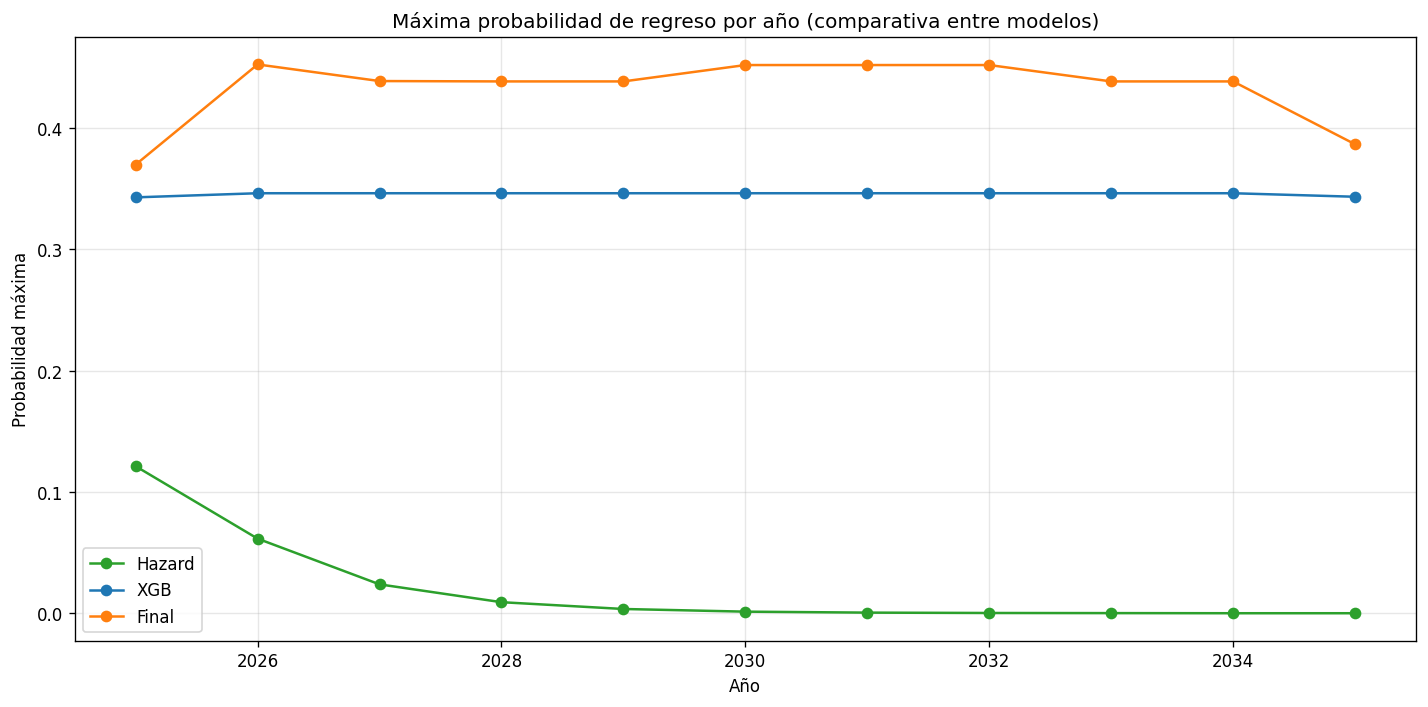

In [71]:
# ==== BLOQUE 10B: Gráfico comparativo anual (máximos por modelo) ====
import matplotlib.pyplot as plt

if 'resumen_models' in globals():
    plt.figure(figsize=(12,6))
    plt.plot(resumen_models['year'], resumen_models['Prob_Hazard'], '-o', label='Hazard', color='#2ca02c')
    plt.plot(resumen_models['year'], resumen_models['Prob_XGB'], '-o', label='XGB', color='#1f77b4')
    plt.plot(resumen_models['year'], resumen_models['Prob_Final'], '-o', label='Final', color='#ff7f0e')

    plt.title("Máxima probabilidad de regreso por año (comparativa entre modelos)")
    plt.xlabel("Año")
    plt.ylabel("Probabilidad máxima")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Ejecuta el bloque 10A antes de graficar.")


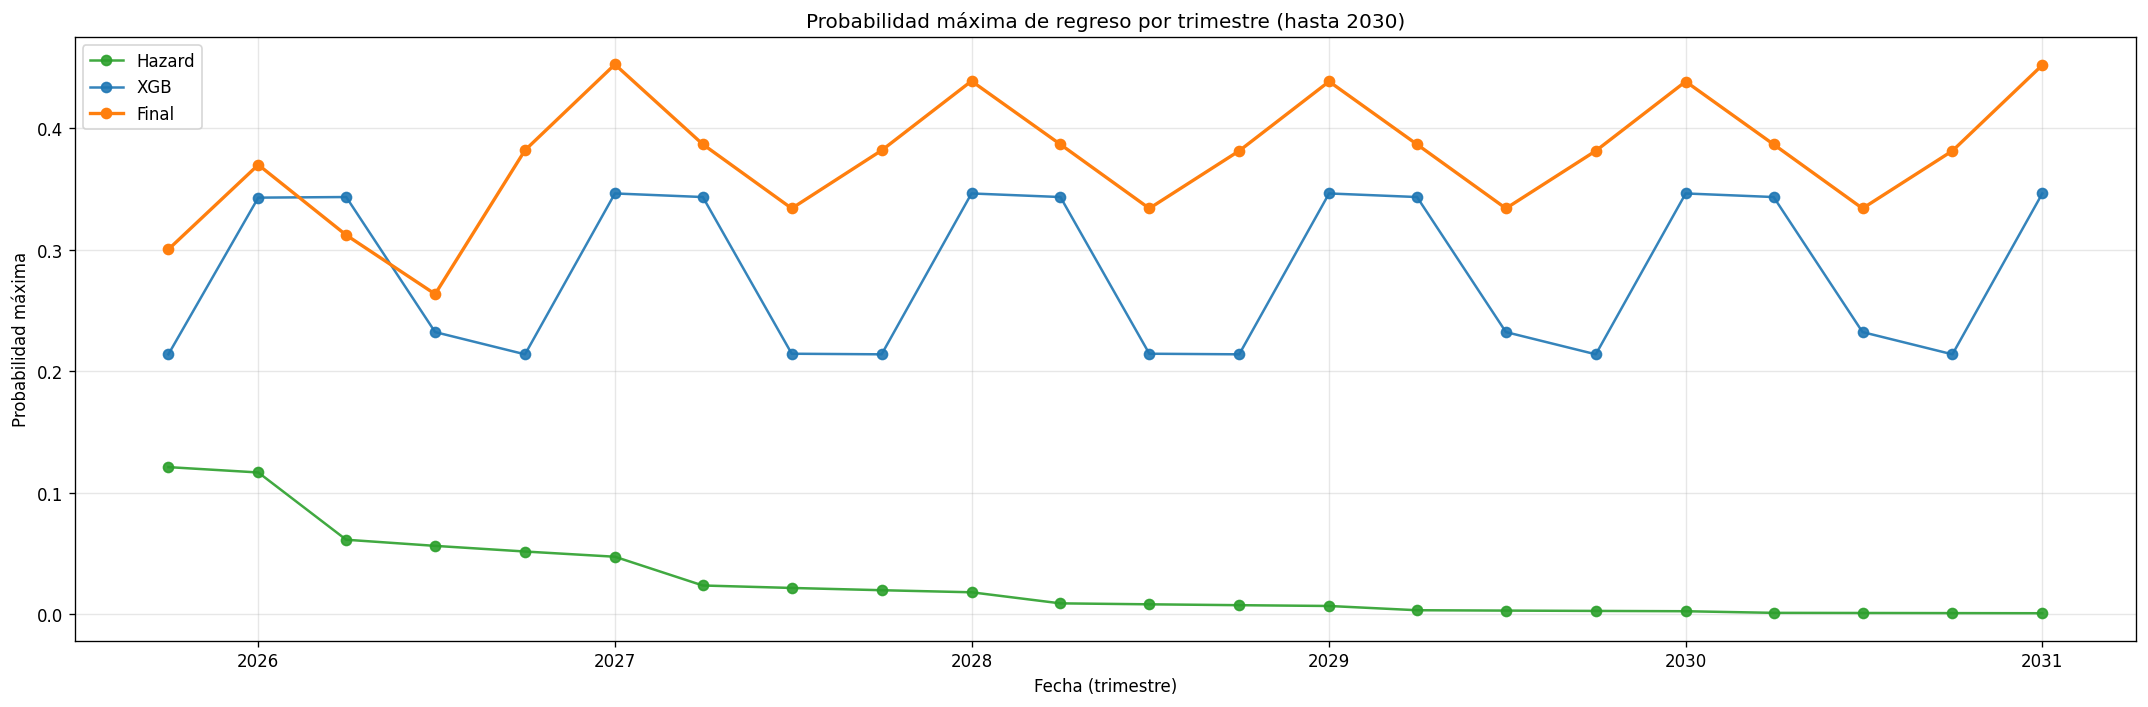

In [77]:
# ==== BLOQUE 10C: Comparativa trimestral de probabilidad (Hazard / XGB / Final) ====
import pandas as pd
import matplotlib.pyplot as plt

# Verificamos que future_df_10y tenga los datos de probabilidad
if 'future_df_10y' not in globals() or 'prob_final' not in future_df_10y.columns:
    print("⚠️ Ejecuta primero el bloque 9E o 10A antes de este.")
else:
    # --- 1) Preparar DataFrame con probabilidades trimestrales ---
    fut = future_df_10y.copy()
    fut['year'] = fut['week_start'].dt.year
    fut = fut[fut['year'] <= 2030]  # límite 2030
    fut['quarter'] = fut['week_start'].dt.to_period('Q').astype(str)
    fut['Fecha'] = fut['week_start'].dt.date

    # Calcular si no existen aún las columnas de prob. individuales
    if 'Hazard' not in fut.columns:
        if 'pipe_hazard' in globals():
            fut['Hazard'] = pipe_hazard.predict_proba(
                fut[['hiatus_streak','run_streak','roll_mean_4','roll_mean_8','lag_1','lag_2','month','iso_week']]
            )[:,1]
        else:
            fut['Hazard'] = 0.0

    if 'XGB' not in fut.columns:
        if 'xgb_cal' in globals():
            fut['XGB'] = xgb_cal.predict_proba(fut[xgb_feats_final].fillna(0))[:,1]
        else:
            fut['XGB'] = 0.0

    fut['Final'] = fut['prob_final']

    # --- 2) Calcular promedios o máximos trimestrales ---
    resumen_trim = (
        fut.groupby('quarter')[['Hazard','XGB','Final']]
           .agg('max')   # puedes cambiar a 'mean' si prefieres promedio
           .reset_index()
    )

    # Extraer fechas centrales de cada trimestre
    resumen_trim['Fecha'] = pd.PeriodIndex(resumen_trim['quarter'], freq='Q').to_timestamp(how='end')

    # --- 3) Graficar evolución trimestral ---
    plt.figure(figsize=(18,6))
    plt.plot(resumen_trim['Fecha'], resumen_trim['Hazard'], '-o', label='Hazard', color='#2ca02c', alpha=0.9)
    plt.plot(resumen_trim['Fecha'], resumen_trim['XGB'], '-o', label='XGB', color='#1f77b4', alpha=0.9)
    plt.plot(resumen_trim['Fecha'], resumen_trim['Final'], '-o', label='Final', color='#ff7f0e', lw=2)

    plt.title("Probabilidad máxima de regreso por trimestre (hasta 2030)")
    plt.xlabel("Fecha (trimestre)")
    plt.ylabel("Probabilidad máxima")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [78]:
# ==== BLOQUE 10D (versión final sin hora, 100% compatible) ====
import pandas as pd

if 'future_df_10y' not in globals() or 'prob_final' not in future_df_10y.columns:
    print("⚠️ Ejecuta el bloque 9E o 10C antes de este.")
else:
    fut = future_df_10y.copy()
    fut['year'] = fut['week_start'].dt.year
    fut = fut[fut['year'] <= 2030]
    fut['quarter'] = fut['week_start'].dt.to_period('Q').astype(str)

    # Calcular probabilidades individuales si no existen
    if 'Hazard' not in fut.columns:
        if 'pipe_hazard' in globals():
            fut['Hazard'] = pipe_hazard.predict_proba(
                fut[['hiatus_streak','run_streak','roll_mean_4','roll_mean_8','lag_1','lag_2','month','iso_week']]
            )[:,1]
        else:
            fut['Hazard'] = 0.0

    if 'XGB' not in fut.columns:
        if 'xgb_cal' in globals():
            fut['XGB'] = xgb_cal.predict_proba(fut[xgb_feats_final].fillna(0))[:,1]
        else:
            fut['XGB'] = 0.0

    fut['Final'] = fut['prob_final']

    # Agrupar por trimestre y calcular promedio
    resumen_full = (
        fut.groupby('quarter')[['Hazard','XGB','Final']]
           .agg('mean')
           .reset_index()
    )

    # Calcular fecha media (convertida correctamente a fecha sin hora)
    per_idx = pd.PeriodIndex(resumen_full['quarter'], freq='Q')
    fecha_inicio = per_idx.to_timestamp(how='S')
    fecha_fin = per_idx.to_timestamp(how='E')
    fecha_media = fecha_inicio + (fecha_fin - fecha_inicio) / 2
    resumen_full['Fecha'] = pd.Series(fecha_media).dt.date  # ✅ conversión segura

    # Promedio general de modelos
    resumen_full['Promedio_Modelos'] = resumen_full[['Hazard','XGB','Final']].mean(axis=1)

    # Reordenar y redondear
    resumen_full = resumen_full[['Fecha','quarter','Hazard','XGB','Final','Promedio_Modelos']].round(4)

    display(resumen_full.head(20))
    resumen_full.to_csv("tabla_trimestral_modelos_promedio.csv", index=False)
    print("💾 Guardado: tabla_trimestral_modelos_promedio.csv (fecha sin hora)")


,Fecha,quarter,Hazard,XGB,Final,Promedio_Modelos
0,2025-08-15,2025Q3,0.1193,0.1617,0.2574,0.1795
1,2025-11-15,2025Q4,0.1090,0.2058,0.2754,0.1967
2,2026-02-14,2026Q1,0.0591,0.2478,0.2801,0.1957
3,2026-05-16,2026Q2,0.0542,0.1615,0.2269,0.1476
4,2026-08-15,2026Q3,0.0497,0.1648,0.3210,0.1785
5,2026-11-15,2026Q4,0.0456,0.2061,0.1926,0.1481
6,2027-02-14,2027Q1,0.0229,0.2498,0.3570,0.2099
7,2027-05-16,2027Q2,0.0209,0.1657,0.2934,0.1600
8,2027-08-15,2027Q3,0.0191,0.1565,0.3267,0.1675
9,2027-11-15,2027Q4,0.0175,0.2141,0.1914,0.1410


💾 Guardado: tabla_trimestral_modelos_promedio.csv (fecha sin hora)
